In [1]:
import uproot as ur
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.optimize import curve_fit

In [2]:
nt = ur.open("res89_99.root")["nt"]
df0 = nt.arrays(library="pd")
## it will be useful later to make a tighter cut on the residuals. 
D=1.5
dft = df0[ (np.abs(df0['xres'])<D) & (np.abs(df0['yres'])<D)]

In [3]:
## preliminary utilities

### fit a 1D histogram
def gauss(x, *p):
    A, mu, sigma = p
    return A*np.exp(-(x-mu)**2/(2.*sigma**2))

def fitHist( h, f=gauss ):
    #centers
    xbinc = (h[1][:-1] + h[1][1:])/2

    # p0 is the initial guess for the fitting coefficients (A, mu and sigma above)
    p0 = [1., 0., 1.]
    coeff, var_matrix = curve_fit(f, xbinc, h[0], p0=p0)
    return coeff, var_matrix

In [4]:
plt.ion();
plt.rcParams["figure.autolayout"] = True
plt.rcParams["figure.dpi"] = 300

## General informations

Schematic view of the readout plane.
<div>
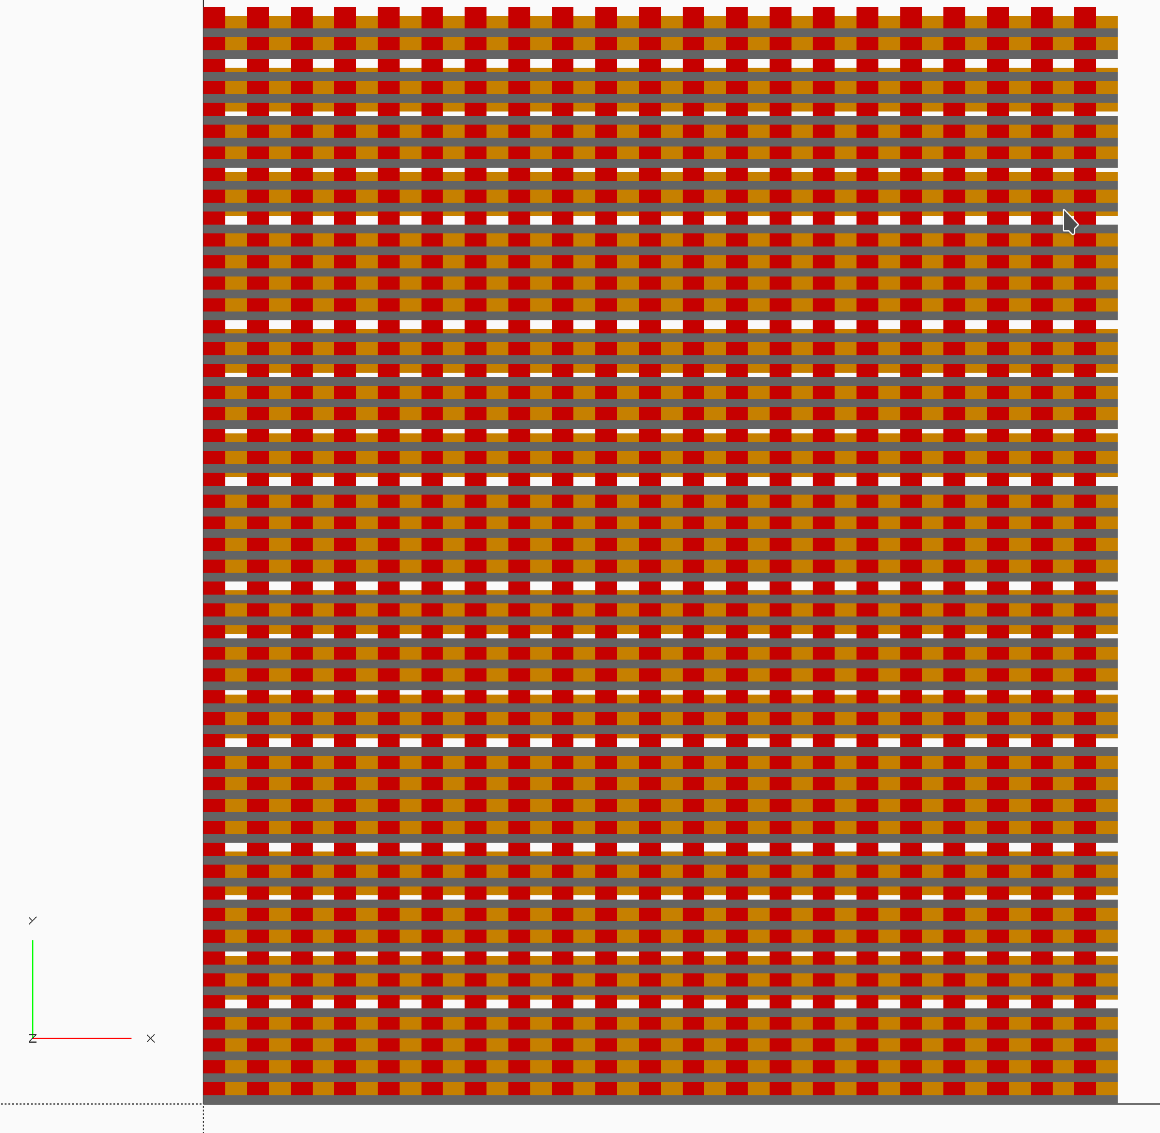
</div>

Dark grey the resistive strips, in read the Y strips (that measure the x coordinate) and the X strips in yellow are the bottom layer that measures the y coordinate

### Info about the analysis

Good BANCO tracks, with $\chi^2/ndf < 2$, are extrapolated to the surface of the detectors.

All pairs of X and Y clusters that *both* are close to the track position ($\delta < 10 mm$) are kept.

## Spatial resolution

Text(0.5, 0, 'yres [mm]')

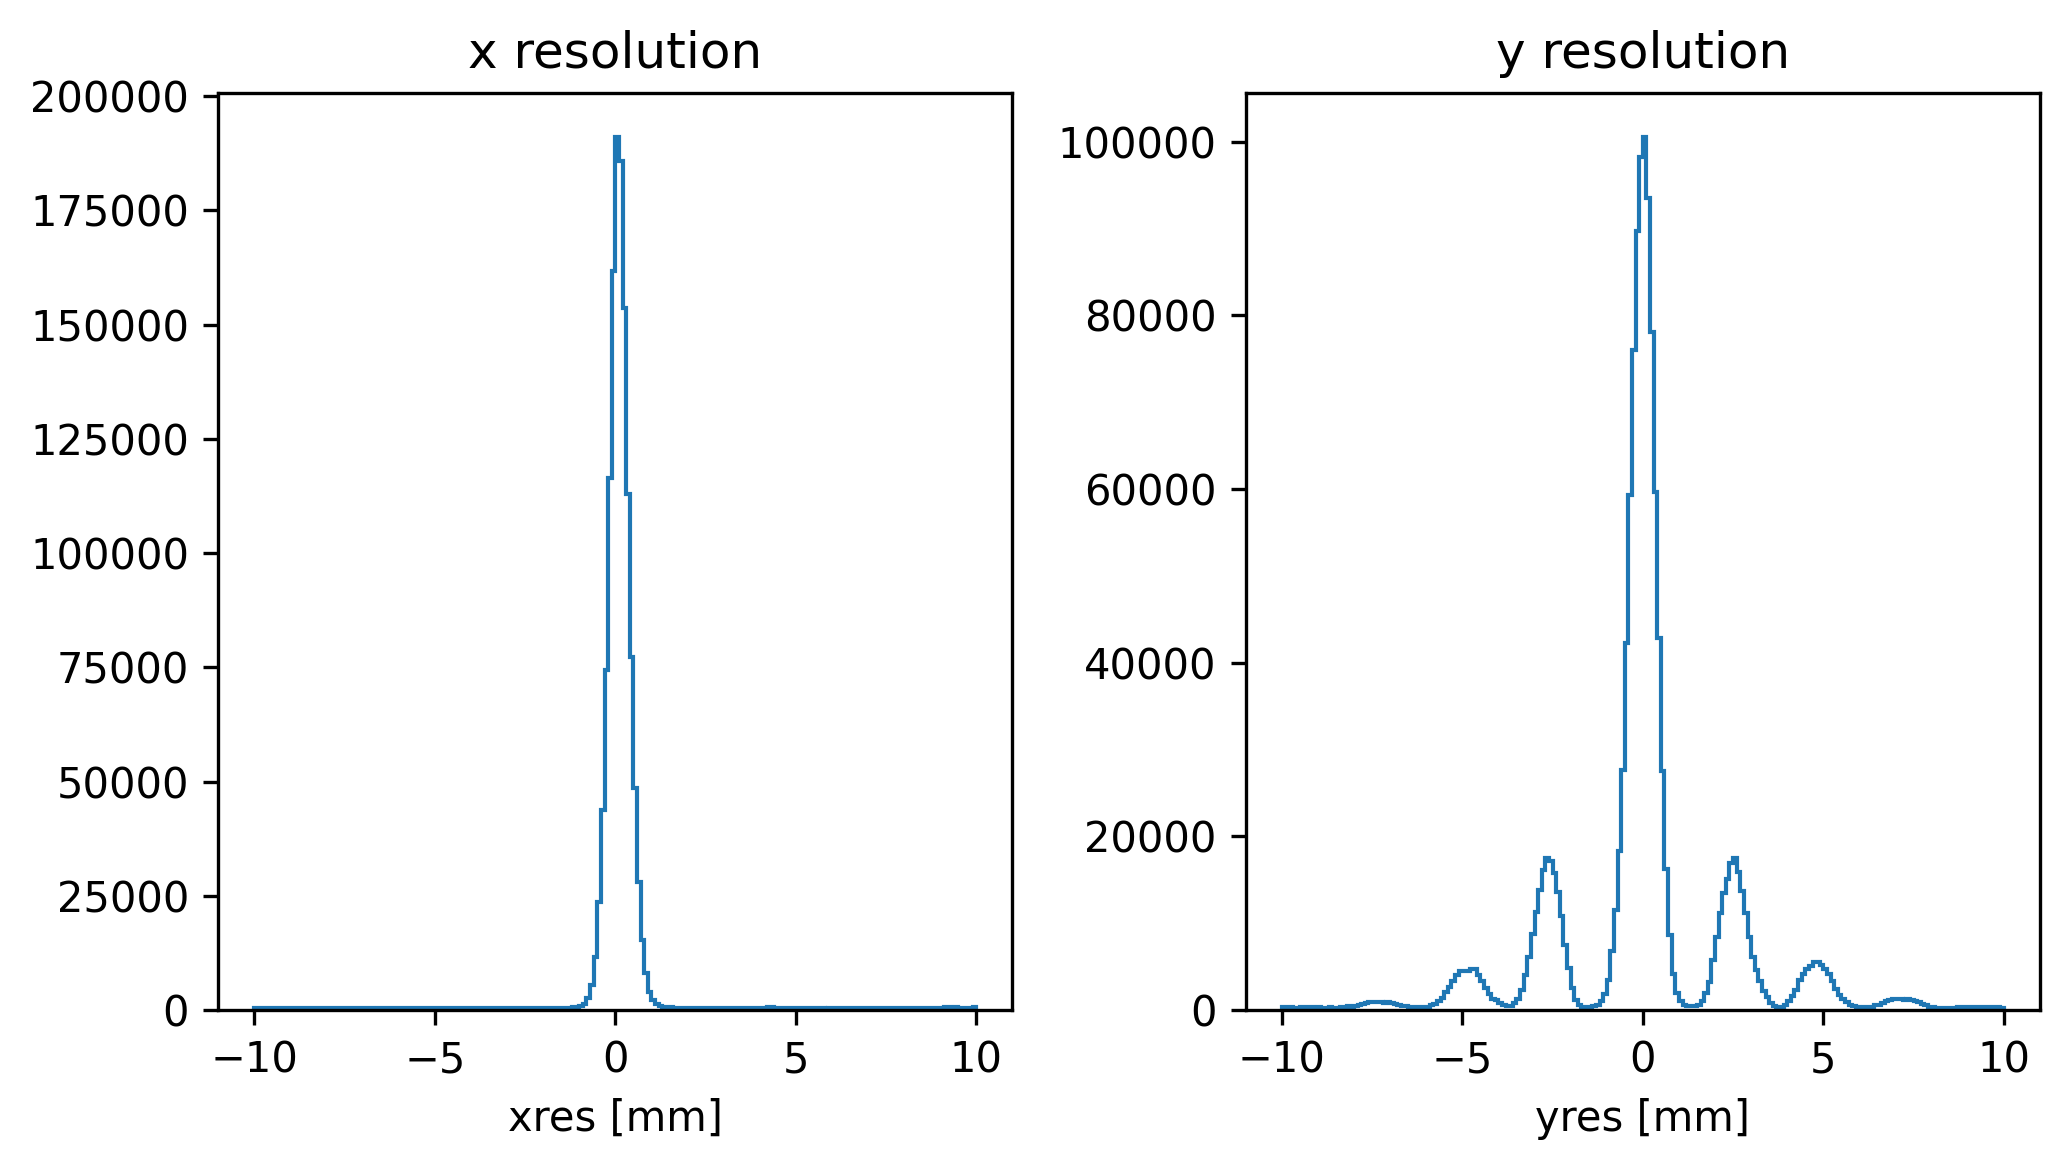

In [5]:
fig = plt.figure( figsize=(7,4) )
ax = fig.add_subplot(121)
ax.set_title("x resolution")
ax.set_xlabel("xres [mm]")
ax.hist( df0['xres'], bins=200, histtype='step' )
ay = fig.add_subplot(122)
ay.hist( df0['yres'], bins=200, histtype='step' )
ay.set_title("y resolution")
ay.set_xlabel("yres [mm]")


Interesting features on the y resoluion. We'll look into it later.
But first, we zoom in and fit with a gaussian.

Text(0.65, 0.7, 'Fit Parameters:\n $\\mu$ = 0.002\n$\\sigma$ = -0.344')

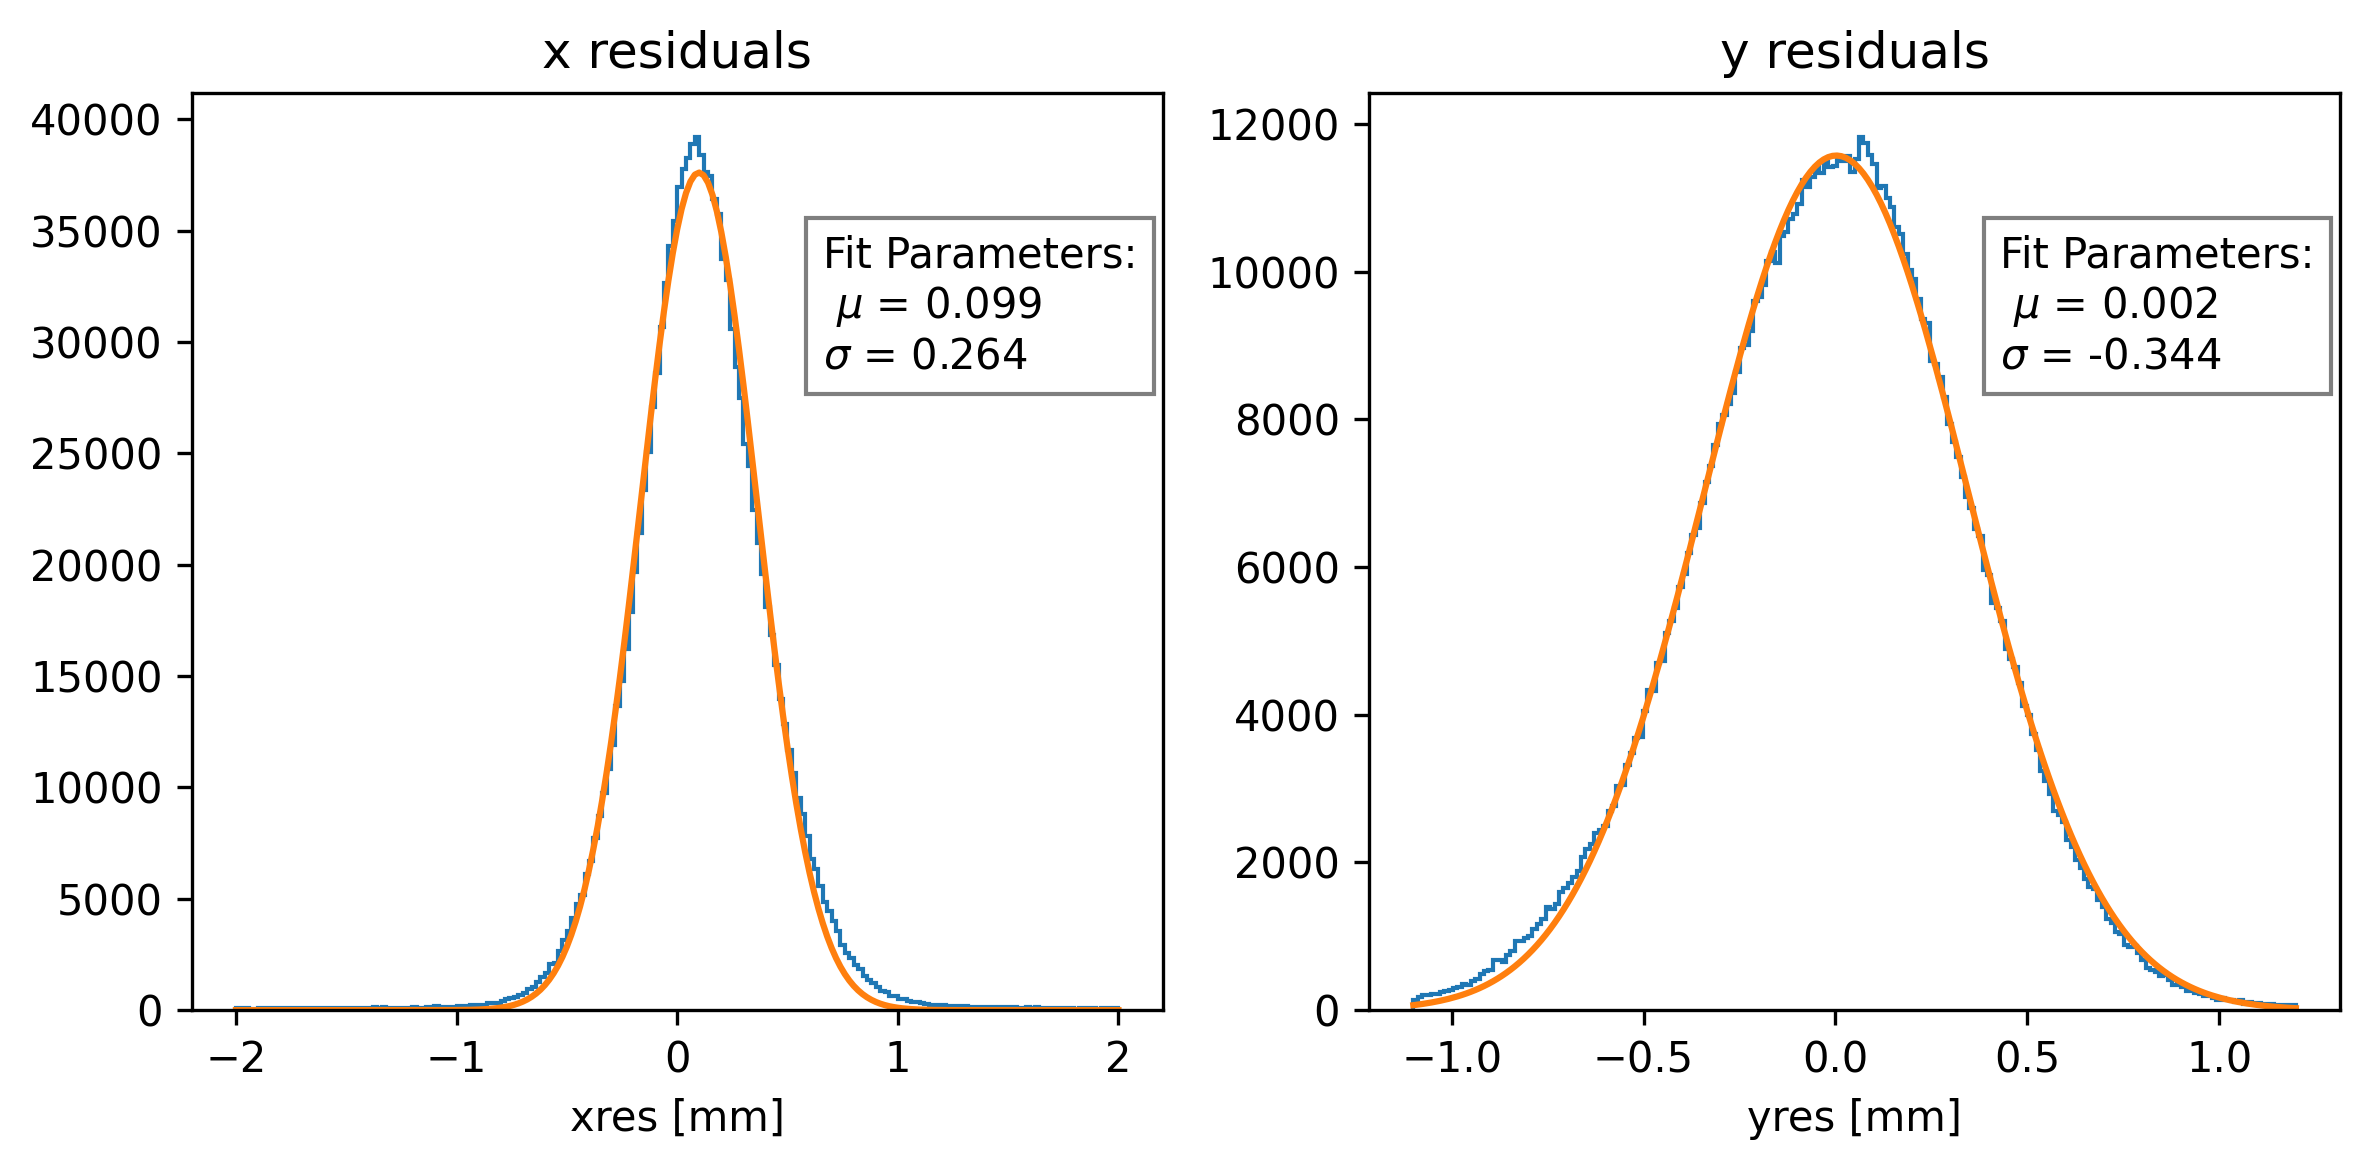

In [6]:
fig = plt.figure( figsize=(8,4) )
ax = fig.add_subplot(121)
ax.set_title("x residuals")
ax.set_xlabel("xres [mm]")
hx = ax.hist( df0['xres'], bins=200, range=(-2.,2.), histtype='step' )
ay = fig.add_subplot(122)
hy = ay.hist( df0['yres'], bins=200, range=(-1.1,1.2), histtype='step' )
ay.set_title("y residuals")
ay.set_xlabel("yres [mm]")

cx, mx = fitHist( hx )
ax.plot( hx[1], gauss(hx[1], *cx) )
fit_text = f'Fit Parameters:\n $\\mu$ = {cx[1]:.3f}\n$\\sigma$ = {cx[2]:.3f}'
ax.text(.65, .7, fit_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.5), transform=ax.transAxes)

cy, my = fitHist( hy )
ay.plot( hy[1], gauss(hy[1], *cy) )
fit_text = f'Fit Parameters:\n $\\mu$ = {cy[1]:.3f}\n$\\sigma$ = {cy[2]:.3f}'
ay.text(.65, .7, fit_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.5), transform=ay.transAxes)

we can also look at how the resolution varies with the position of the track on the detector

Text(0.5, 0, 'x track [mm]')

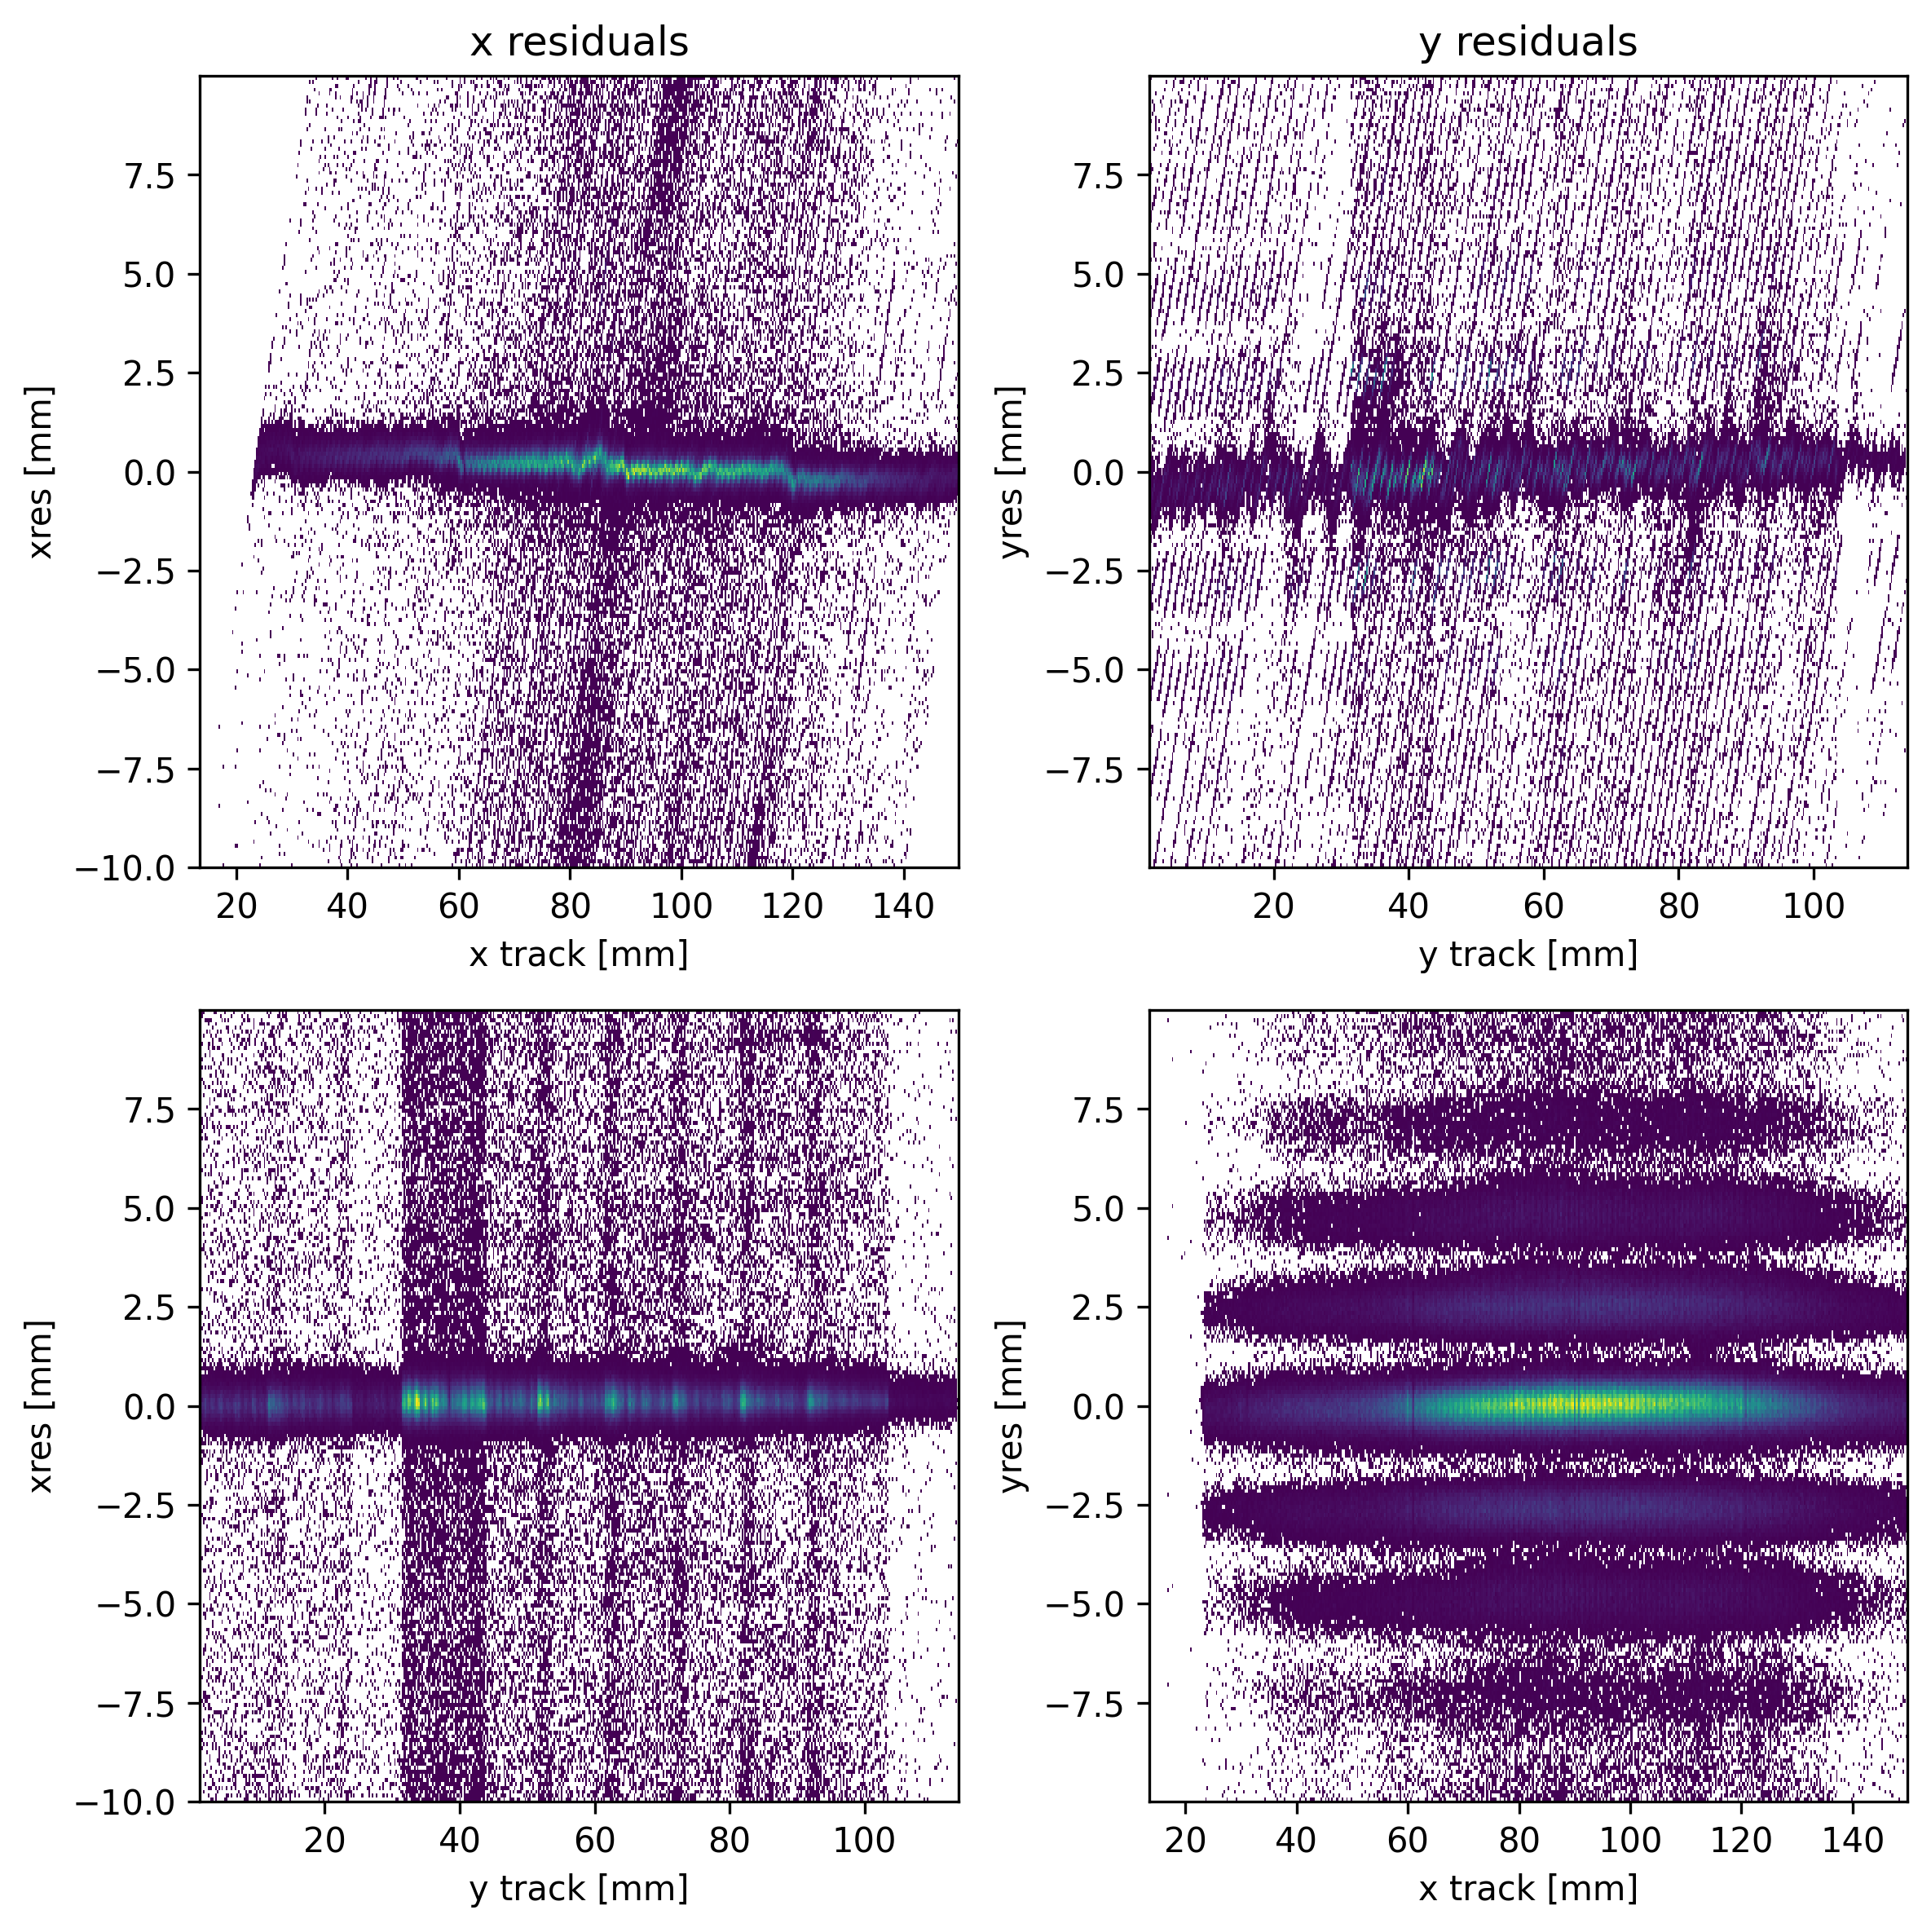

In [7]:
fig = plt.figure( figsize=(8,8) )
ax = fig.add_subplot(221)
ax.set_title("x residuals")
ax.set_ylabel("xres [mm]")
ax.set_xlabel("x track [mm]")
hx = ax.hist2d( df0['xtr'],df0['xres'], bins=(500,200), cmin=1 )
ay = fig.add_subplot(222)
hy = ay.hist2d( df0['ytr'],df0['yres'], bins=(500,200), cmin=1 )
ay.set_title("y residuals")
ay.set_ylabel("yres [mm]")
ay.set_xlabel("y track [mm]")
ax = fig.add_subplot(223)
ax.set_ylabel("xres [mm]")
ax.set_xlabel("y track [mm]")
hx = ax.hist2d( df0['ytr'],df0['xres'], bins=(500,200), cmin=1 )
ay = fig.add_subplot(224)
hy = ay.hist2d( df0['xtr'],df0['yres'], bins=(500,200), cmin=1 )
# ay.set_title("y residuals")
ay.set_ylabel("yres [mm]")
ay.set_xlabel("x track [mm]")

### Cluster size

Let's look at the cluster size

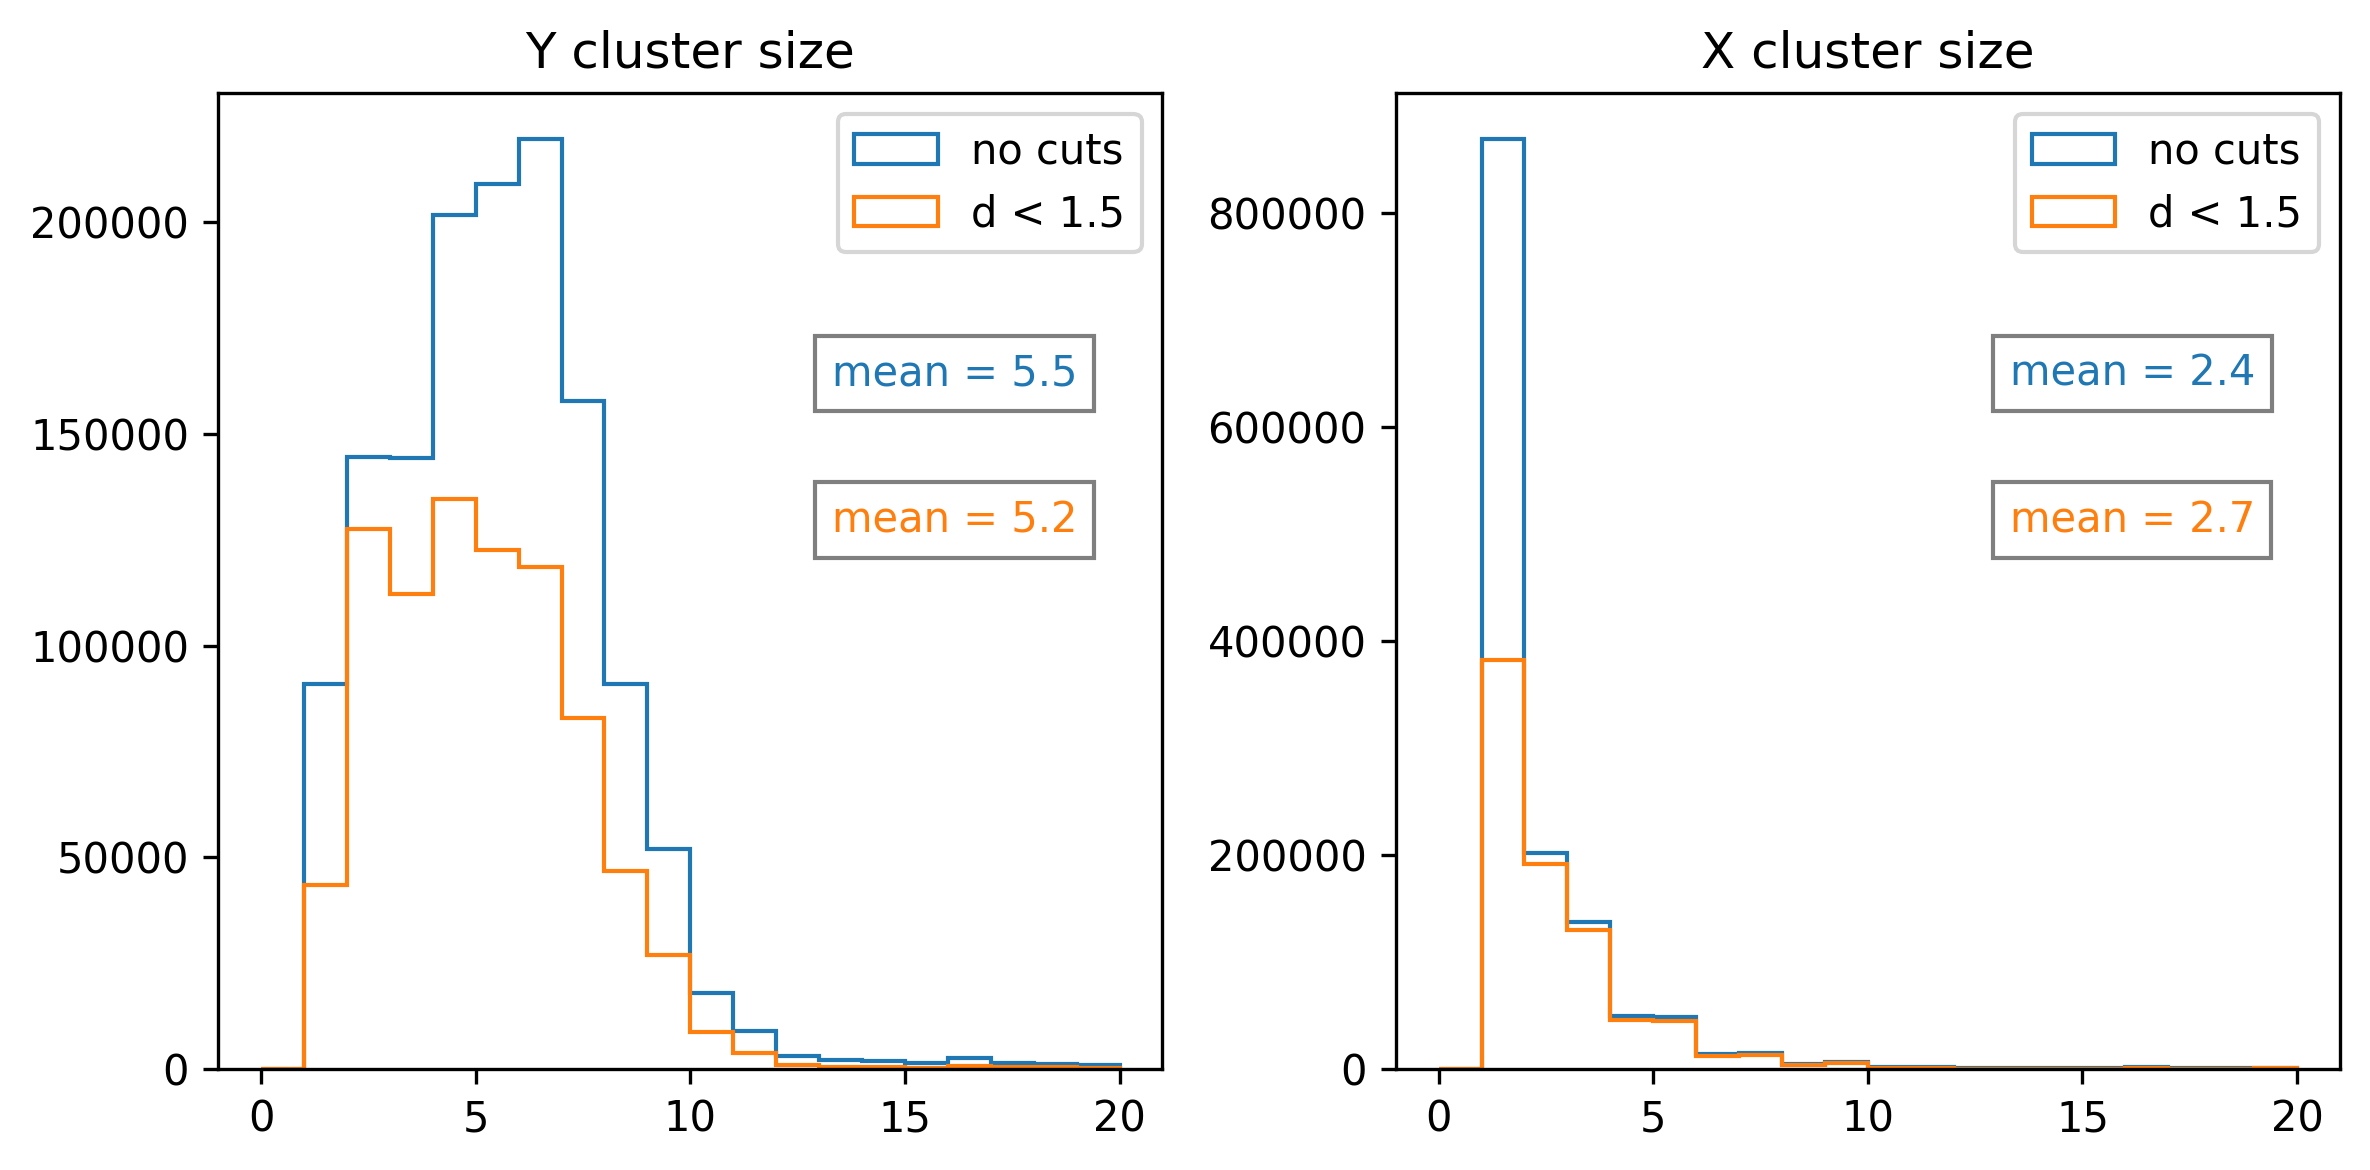

In [8]:
fig = plt.figure( figsize=(8,4) )
ax = fig.add_subplot(121)
ax.set_title("Y cluster size")
# ax.set_xlabel("")
hx = ax.hist( df0['Yclsize'], bins=20, range=(0,20), histtype='step', label="no cuts" )
ay = fig.add_subplot(122)
hy = ay.hist( df0['Xclsize'], bins=20, range=(0,20), histtype='step', label="no cuts" )
ay.set_title("X cluster size")
# ay.set_xlabel("yres [mm]")

## let's add on top the plot of the clusters closer to the track, d < 1.5 mm
hxt = ax.hist( dft['Yclsize'], bins=20, range=(0,20), histtype='step', label=f'd < {D:.1f}' )
hyt = ay.hist( dft['Xclsize'], bins=20, range=(0,20), histtype='step', label=f'd < {D:.1f}' )

hxmean  = np.average( (hx[1][1:]+hx[1][:-1])/2, weights=hx[0])
hxtmean = np.average( (hxt[1][1:]+hxt[1][:-1])/2, weights=hxt[0])

text = f'mean = {hxmean:.1f}'
ax.text(.65, .7, text, fontsize=10, color='tab:blue', bbox=dict(facecolor='white', alpha=0.5), transform=ax.transAxes)
text = f'mean = {hxtmean:.1f}'
ax.text(.65, .55, text, fontsize=10, color='tab:orange', bbox=dict(facecolor='white', alpha=0.5), transform=ax.transAxes)


hymean  = np.average( (hy[1][1:]+hy[1][:-1])/2, weights=hy[0])
hytmean = np.average( (hyt[1][1:]+hyt[1][:-1])/2, weights=hyt[0])

text = f'mean = {hymean:.1f}'
ay.text(.65, .7, text, fontsize=10, color='tab:blue', bbox=dict(facecolor='white', alpha=0.5), transform=ay.transAxes)
text = f'mean = {hytmean:.1f}'
ay.text(.65, .55, text, fontsize=10, color='tab:orange', bbox=dict(facecolor='white', alpha=0.5), transform=ay.transAxes)

ax.legend(loc="upper right")
ay.legend(loc="upper right")


In [9]:
### Let's make datasets with a cut in cluster size
df0Xcls1 = df0[ df0['Xclsize'] == 1 ]
df0Ycls1 = df0[ df0['Yclsize'] == 1 ]

df0XclsL = df0[ df0['Xclsize'] > 1 ]
df0YclsL = df0[ df0['Yclsize'] > 1 ]

### Time of max distribution

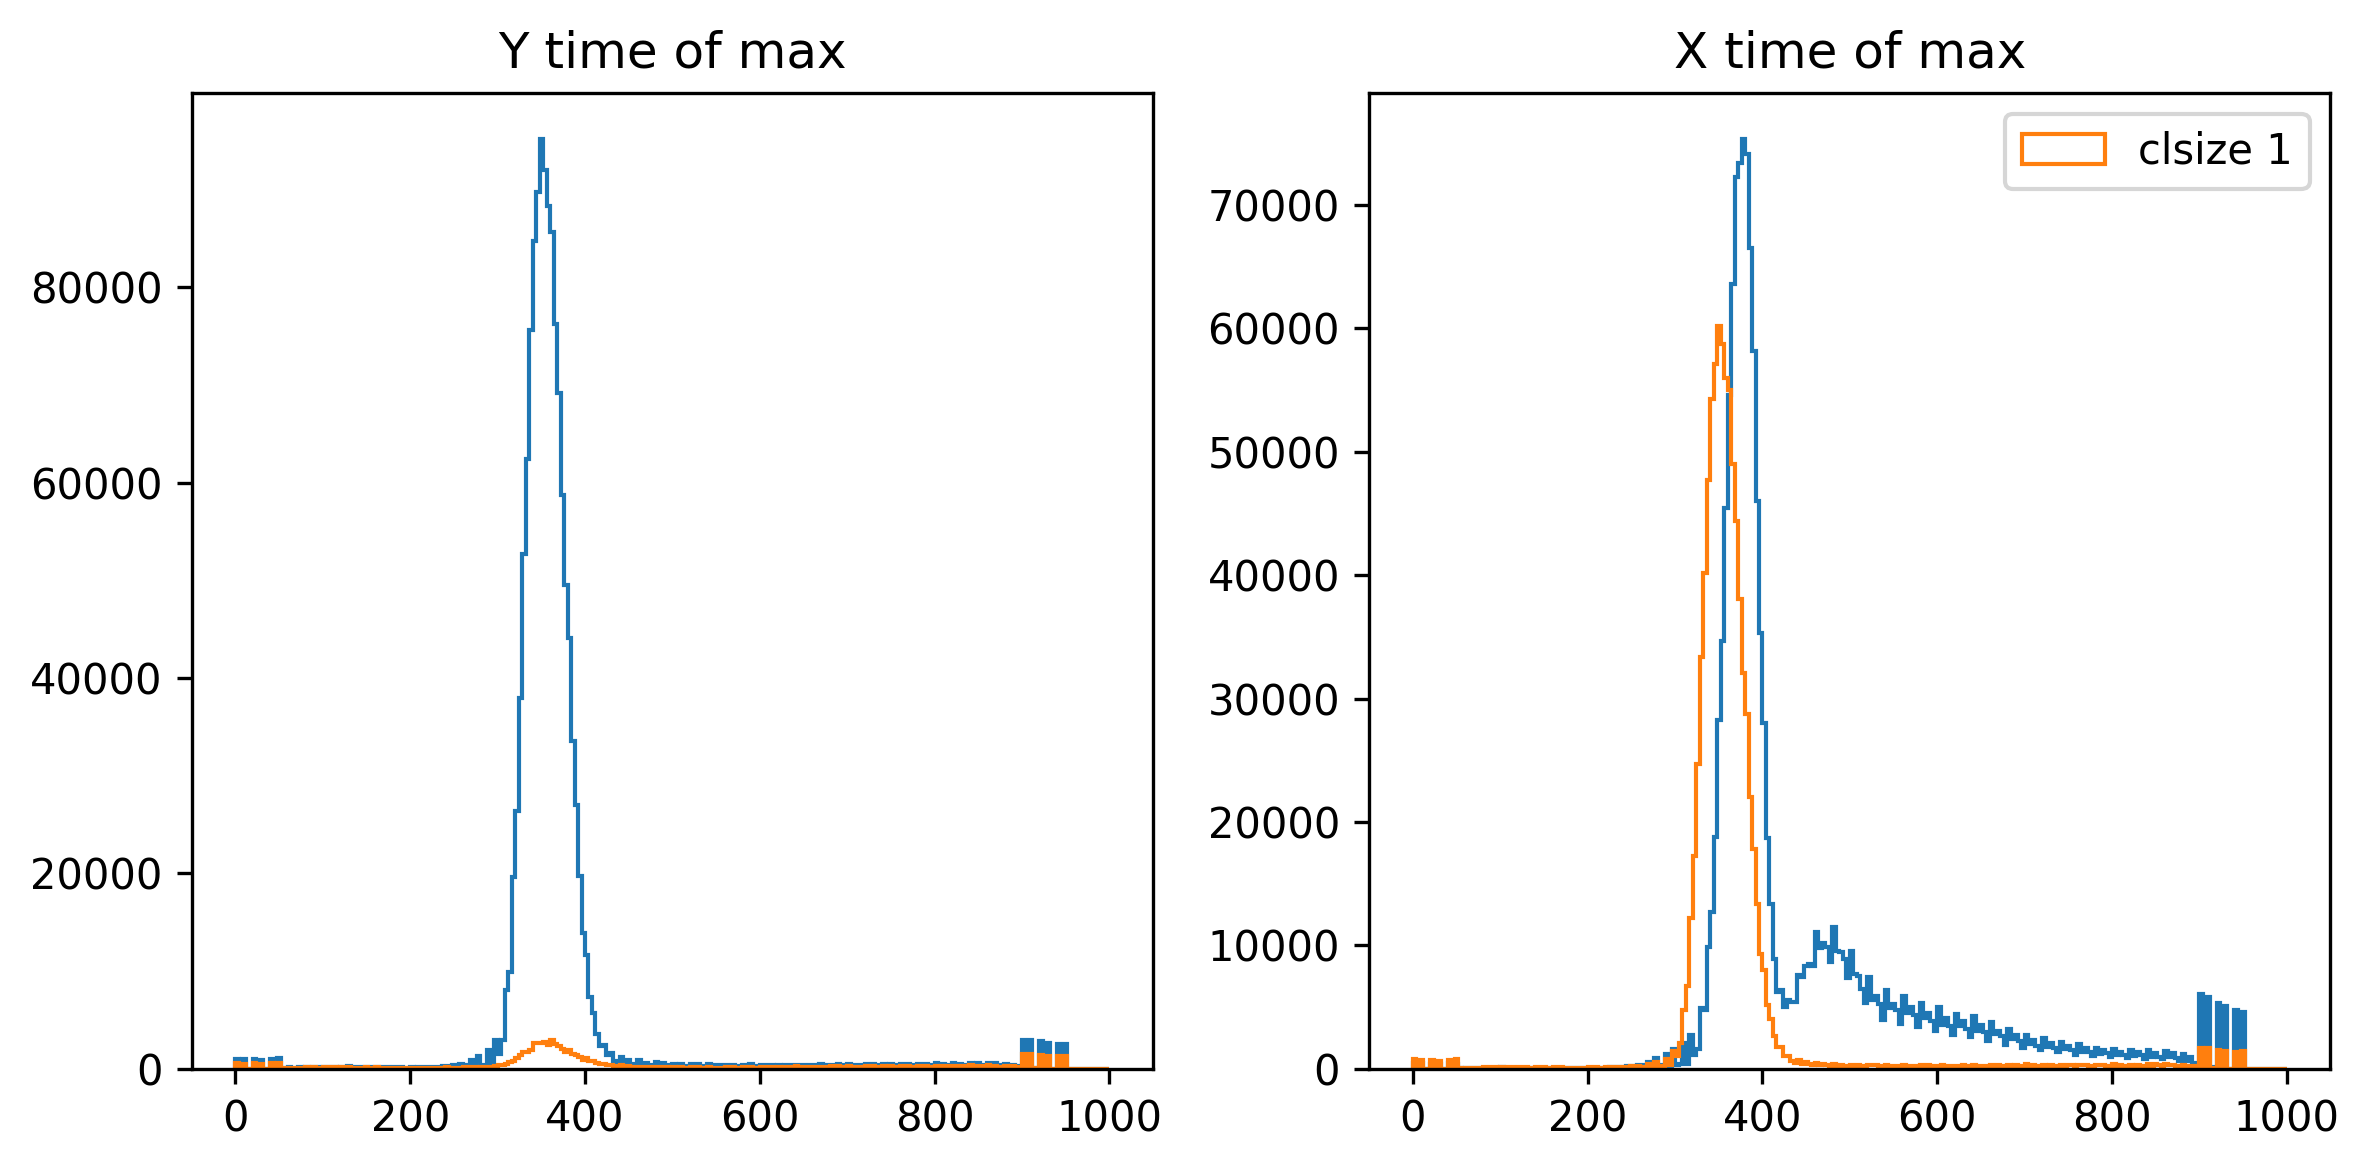

In [10]:
fig = plt.figure( figsize=(8,4) )
ax = fig.add_subplot(121)
ax.set_title("Y time of max")
ax.hist( df0["Yt"] , bins=250, range=(0,1000), histtype='step' );
ax.hist( df0Ycls1["Yt"] , bins=250, range=(0,1000), histtype='step', label="clsize 1" );

ay = fig.add_subplot(122)
ay.set_title("X time of max")
ay.hist( df0["Xt"] , bins=250, range=(0,1000), histtype='step' );
ay.hist( df0Xcls1["Yt"] , bins=250, range=(0,1000), histtype='step', label="clsize 1" );
ay.legend()

Interesting feature for the X strips (reminder, they measure the y coordinate): it looks like that a lot of size-one clusters are delayed.

Let's look at some correlations


#### correlations of Y and X time

Text(0.5, 1.0, 'Xclsize > 1')

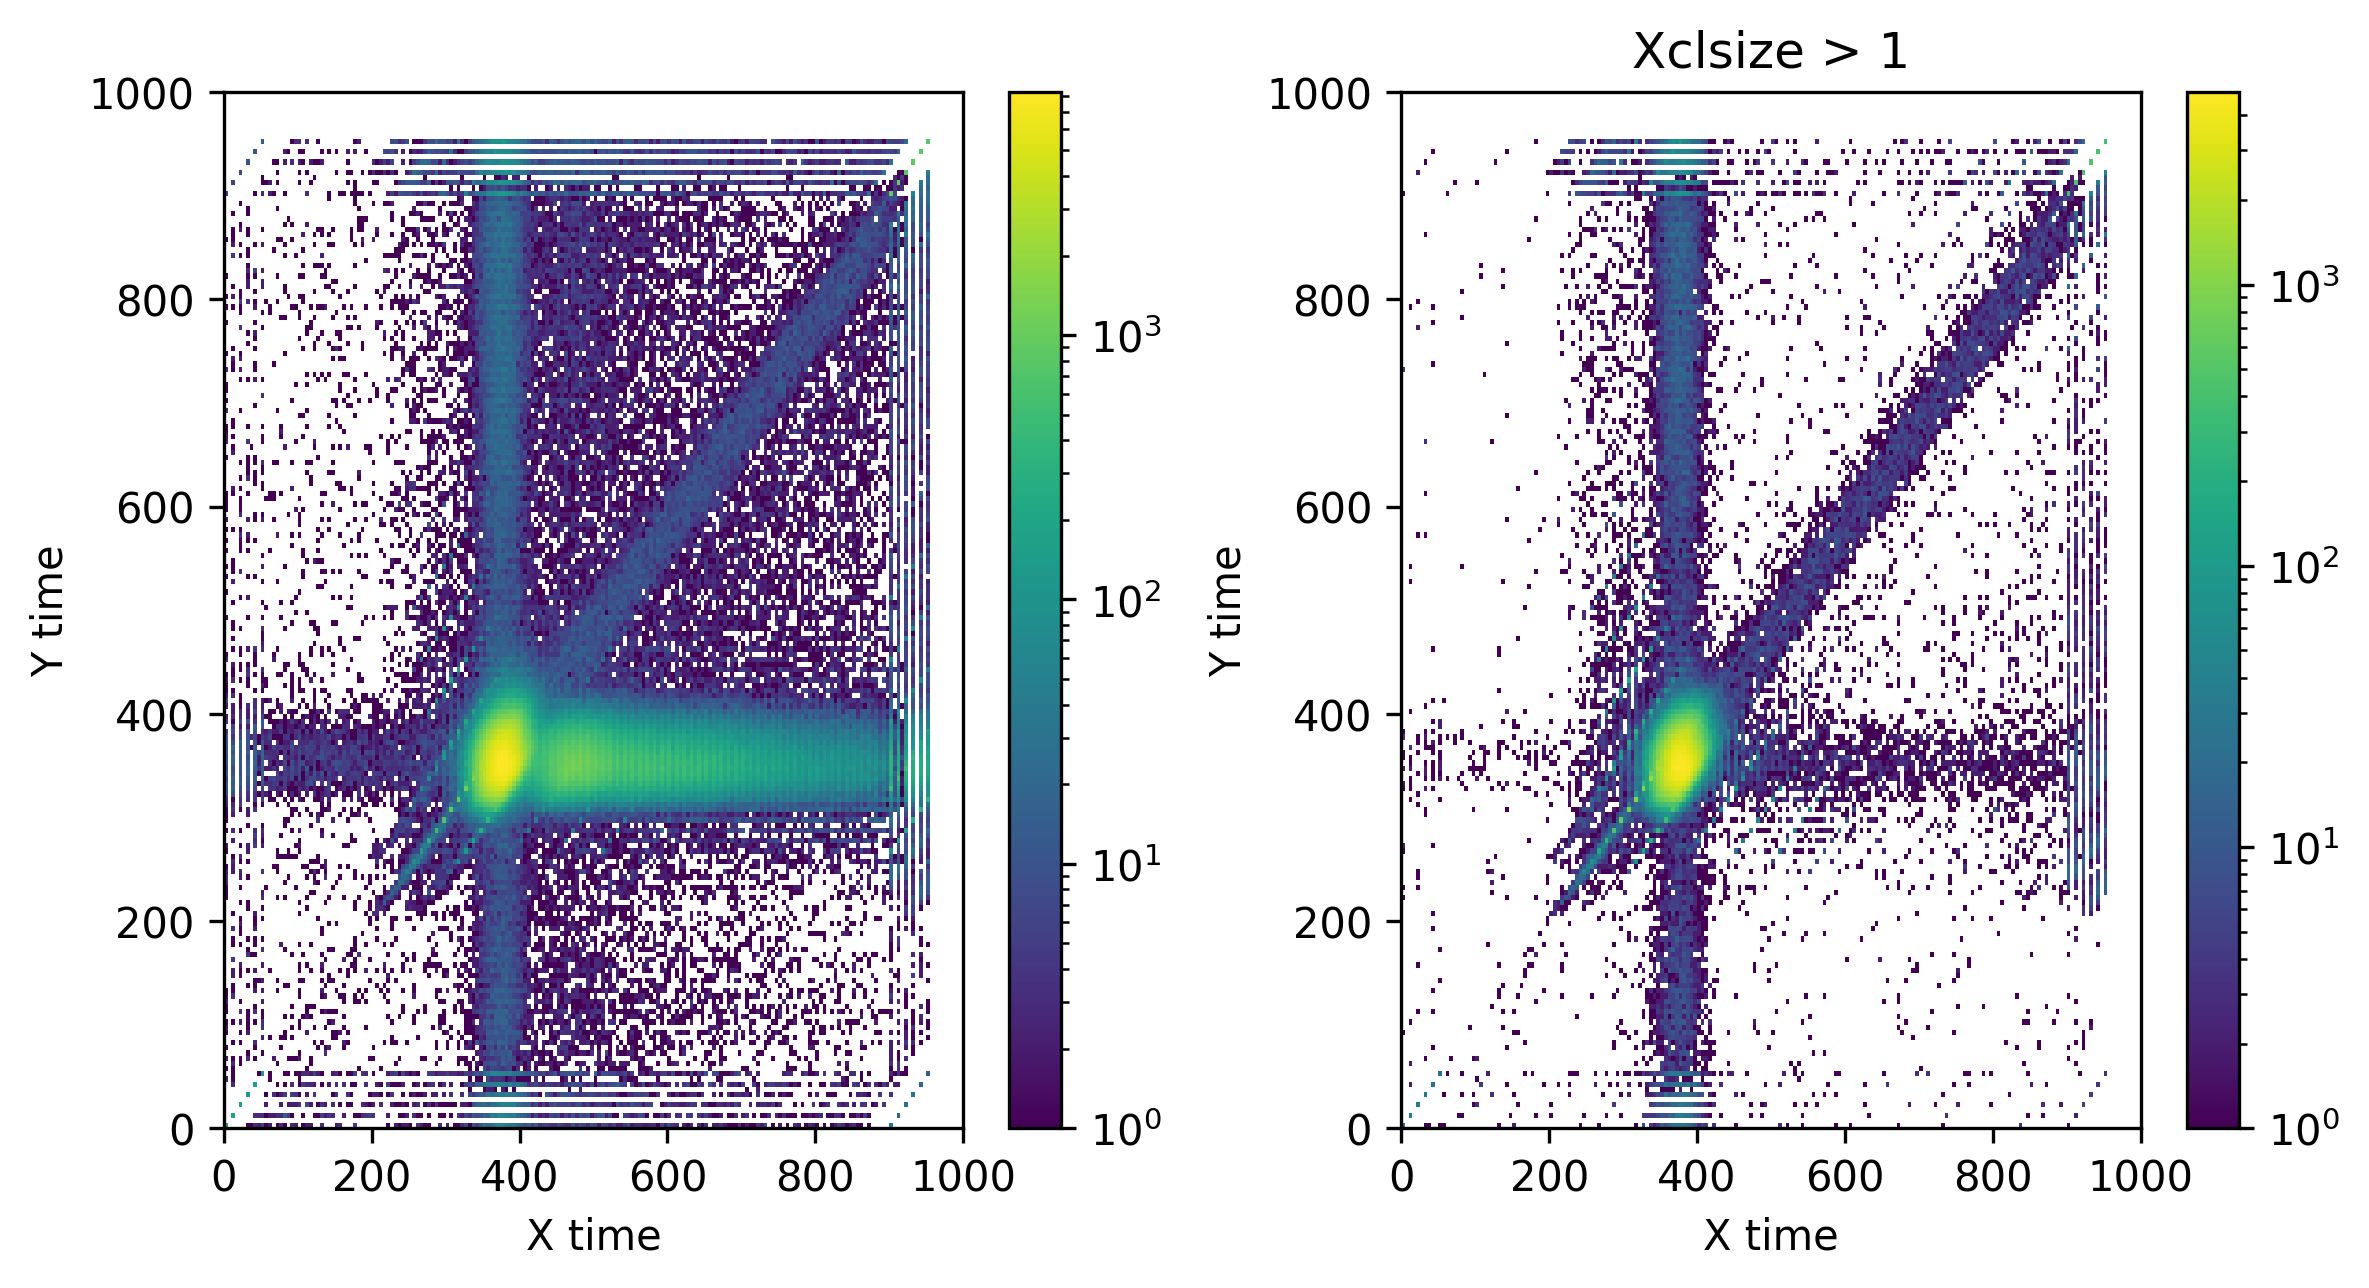

In [11]:
## 

fig = plt.figure( figsize=(8,8) )
ax = fig.add_subplot(221)
hx = ax.hist2d( df0['Xt'],df0['Yt'], bins=(200,200), range=[ [0,1000],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("Y time")
ax.set_xlabel("X time")

ax = fig.add_subplot(222)
hx = ax.hist2d( df0XclsL['Xt'],df0XclsL['Yt'], bins=(200,200), range=[ [0,1000],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("Y time")
ax.set_xlabel("X time")
ax.set_title("Xclsize > 1")


#### Correlation of X time of max with the residuals of the track

Text(0.5, 1.0, 'Xclsize > 1')

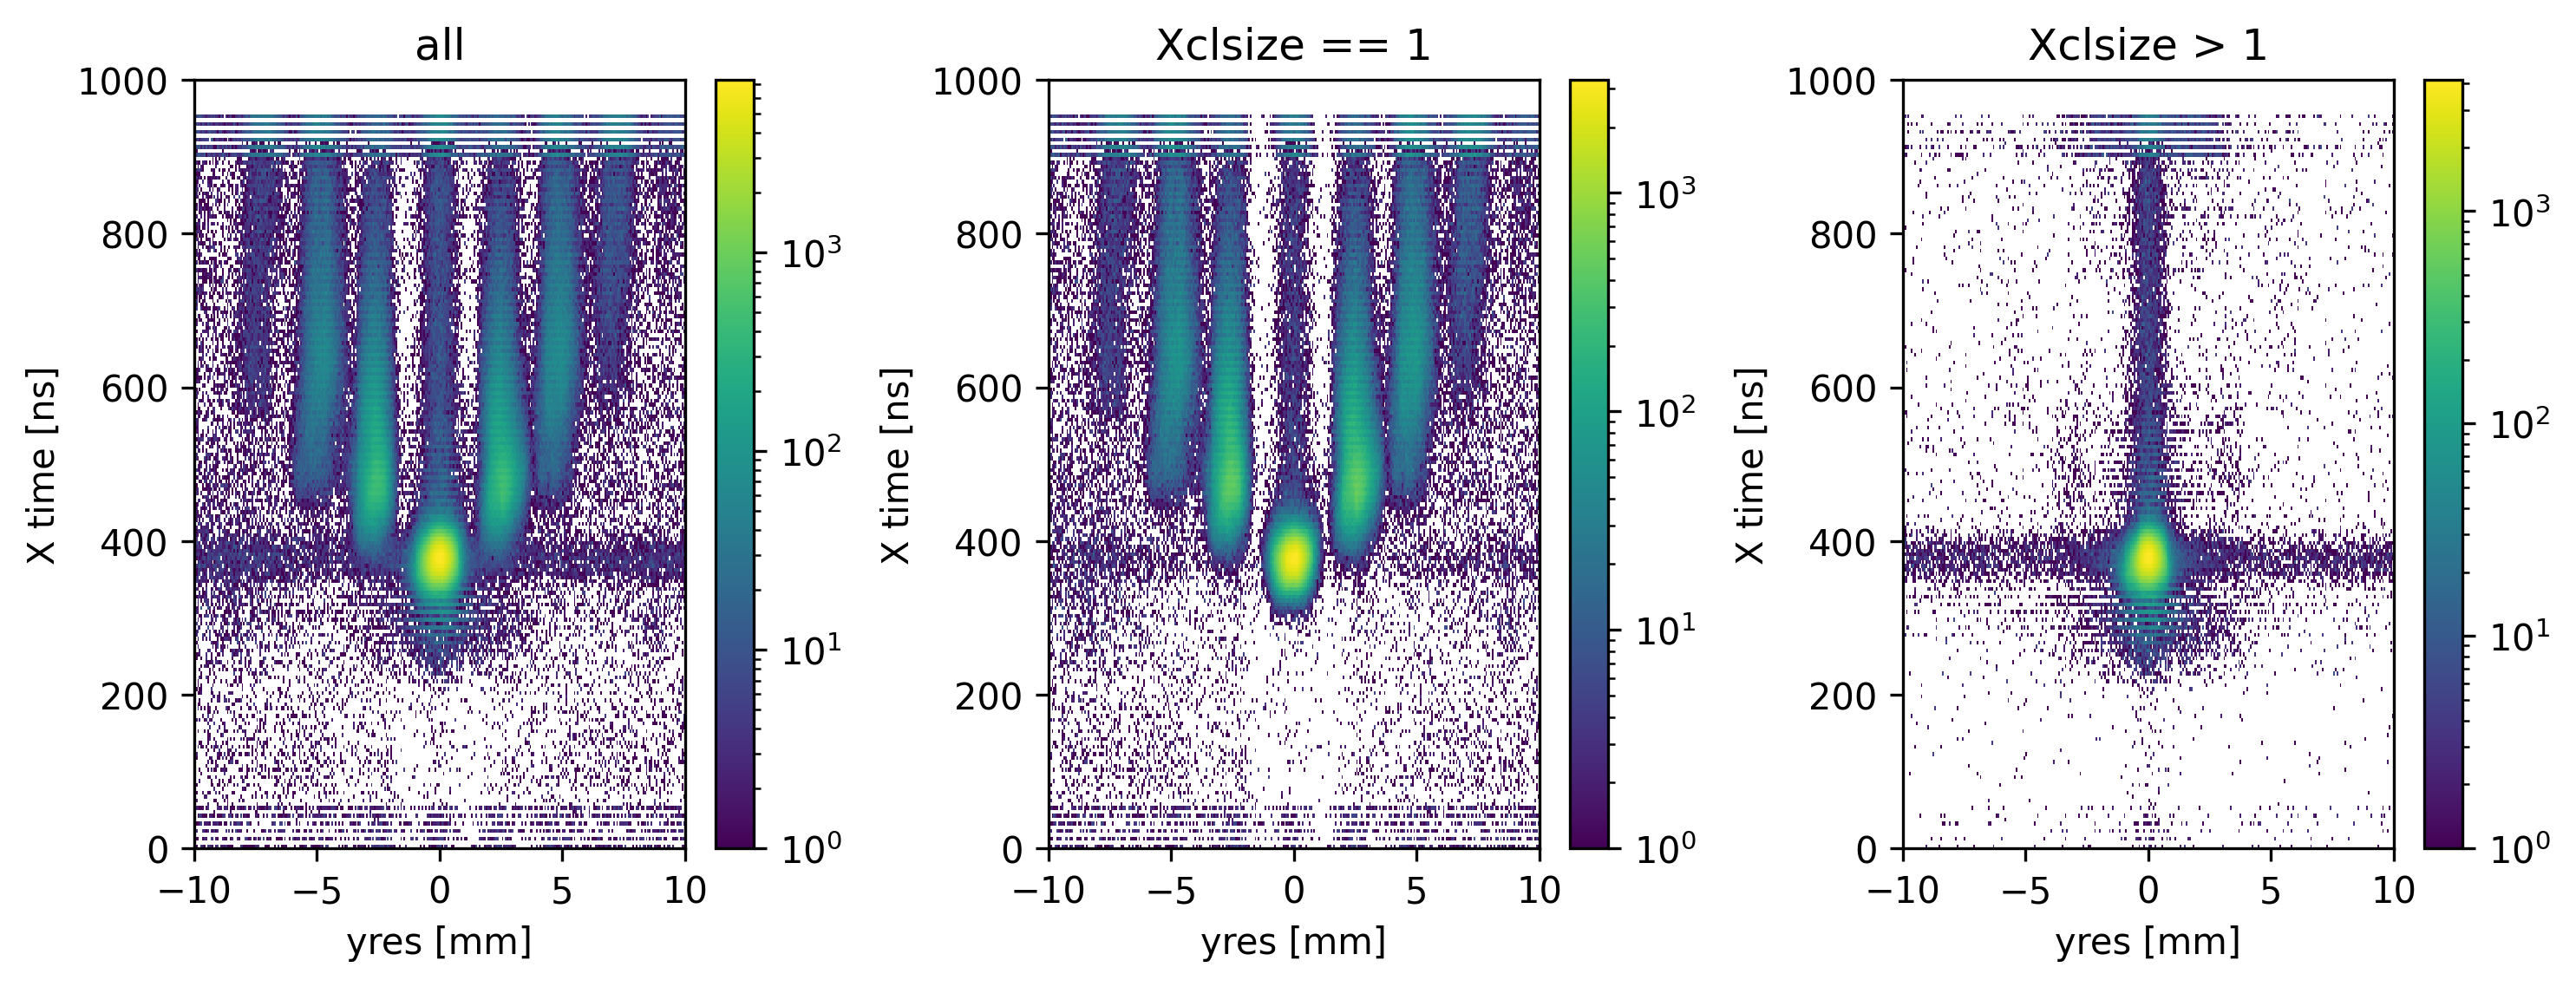

In [12]:
## 

fig = plt.figure( figsize=(10,7) )
ax = fig.add_subplot(231)
hx = ax.hist2d( df0['yres'],df0['Xt'], bins=(300,200), range=[ [-10,10],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("yres [mm]")
ax.set_title("all")

ax = fig.add_subplot(232)
hx = ax.hist2d( df0Xcls1['yres'],df0Xcls1['Xt'], bins=(300,200), range=[ [-10,10],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("yres [mm]")
ax.set_title("Xclsize == 1")

ax = fig.add_subplot(233)
hx = ax.hist2d( df0XclsL['yres'],df0XclsL['Xt'], bins=(300,200), range=[ [-10,10],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("yres [mm]")
ax.set_title("Xclsize > 1")

#### Is there any coorrelation with the x residuals?

no, there is no correlation.

Text(0.5, 1.0, 'Xclsize > 1')

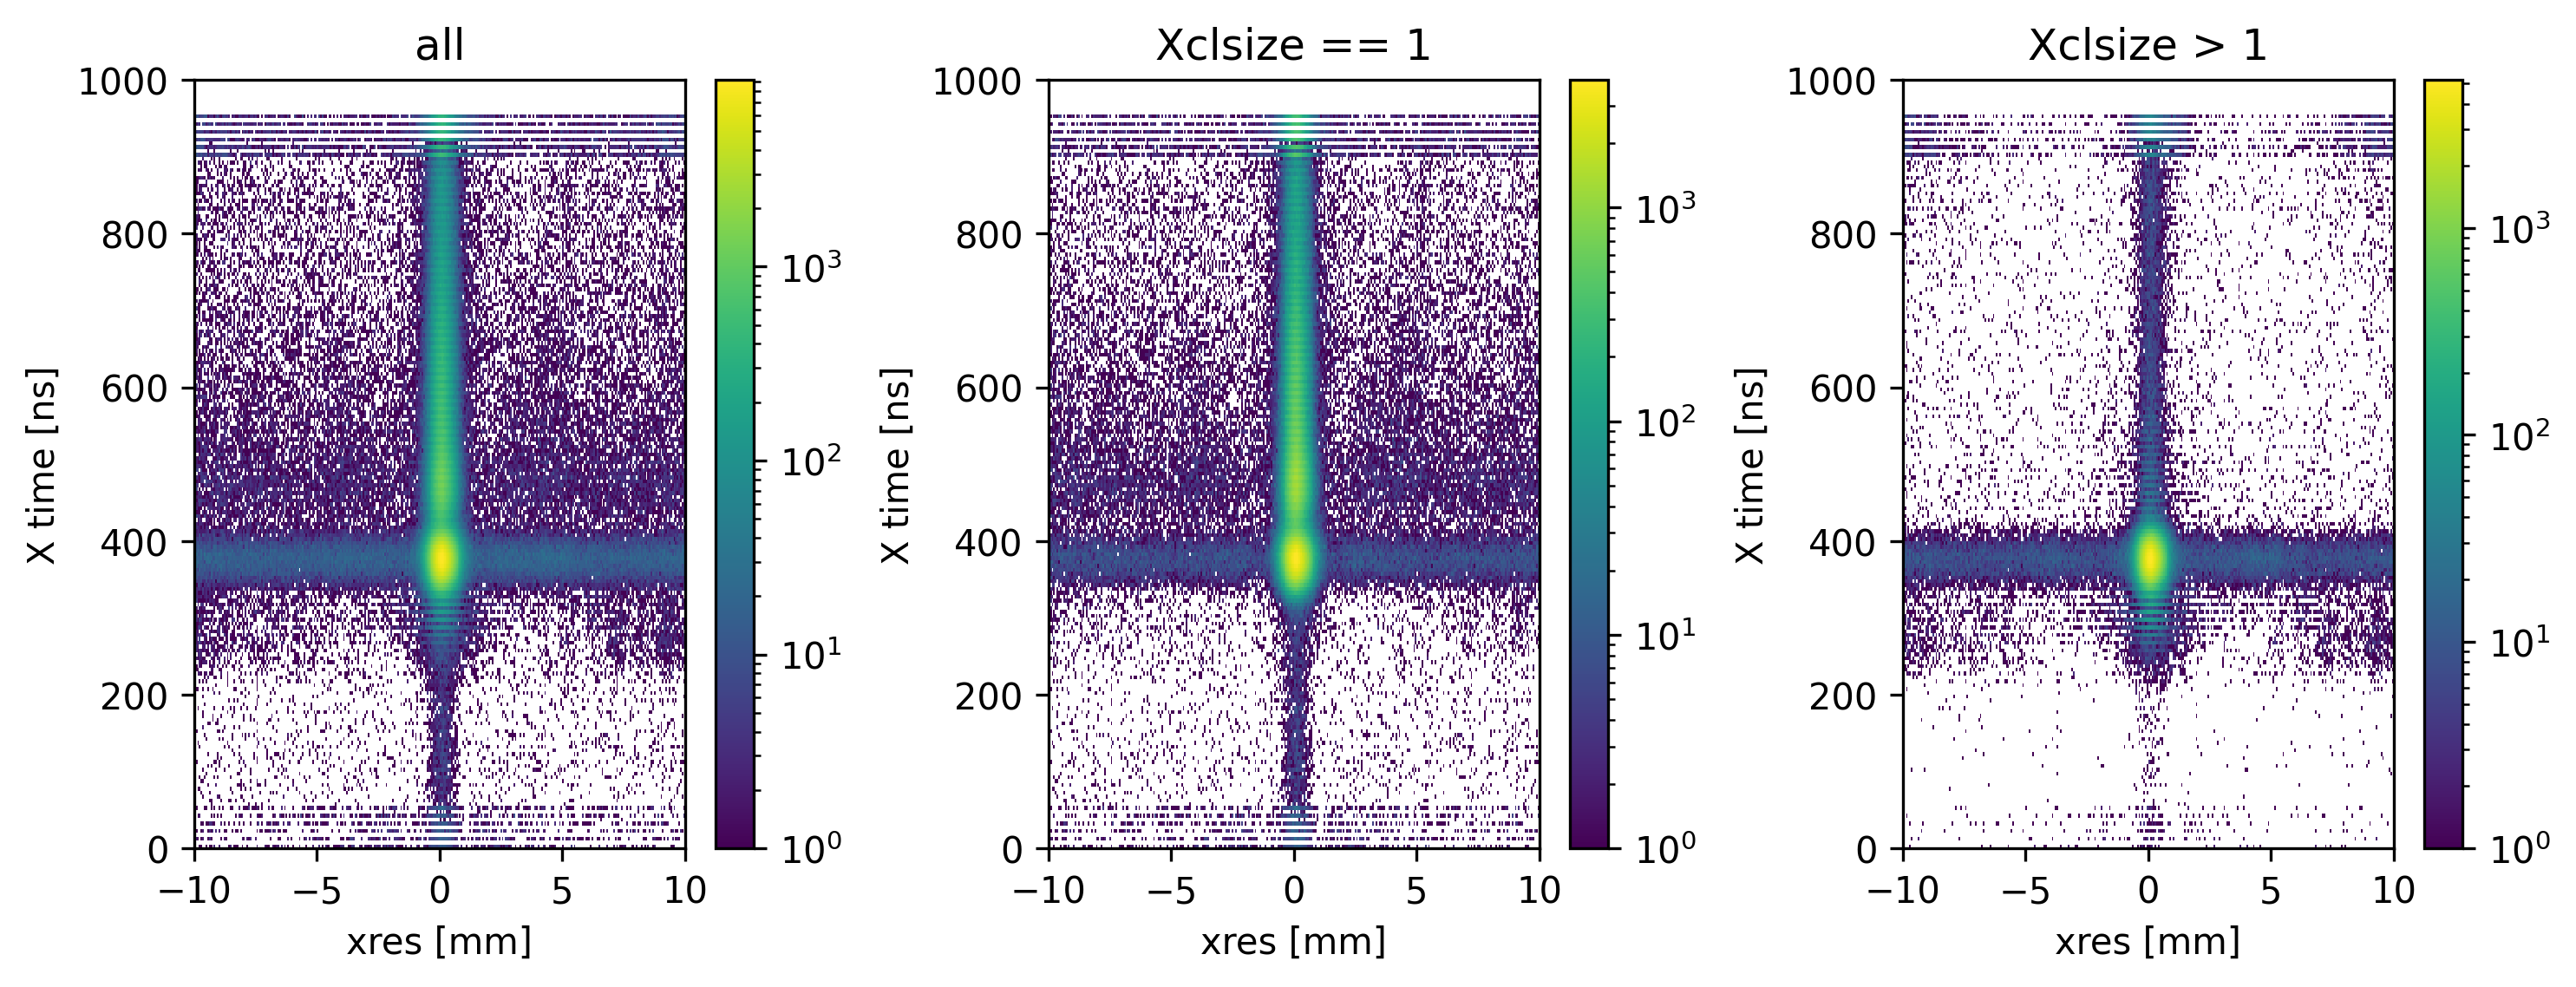

In [13]:
fig = plt.figure( figsize=(10,7) )
ax = fig.add_subplot(231)
hx = ax.hist2d( df0['xres'],df0['Xt'], bins=(300,200), range=[ [-10,10],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("xres [mm]")
ax.set_title("all")

ax = fig.add_subplot(232)
hx = ax.hist2d( df0Xcls1['xres'],df0Xcls1['Xt'], bins=(300,200), range=[ [-10,10],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("xres [mm]")
ax.set_title("Xclsize == 1")

ax = fig.add_subplot(233)
hx = ax.hist2d( df0XclsL['xres'],df0XclsL['Xt'], bins=(300,200), range=[ [-10,10],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("xres [mm]")
ax.set_title("Xclsize > 1")

#### is the effect uniform over the detector?

##### X strips

Text(0.5, 0, 'ytr [mm]')

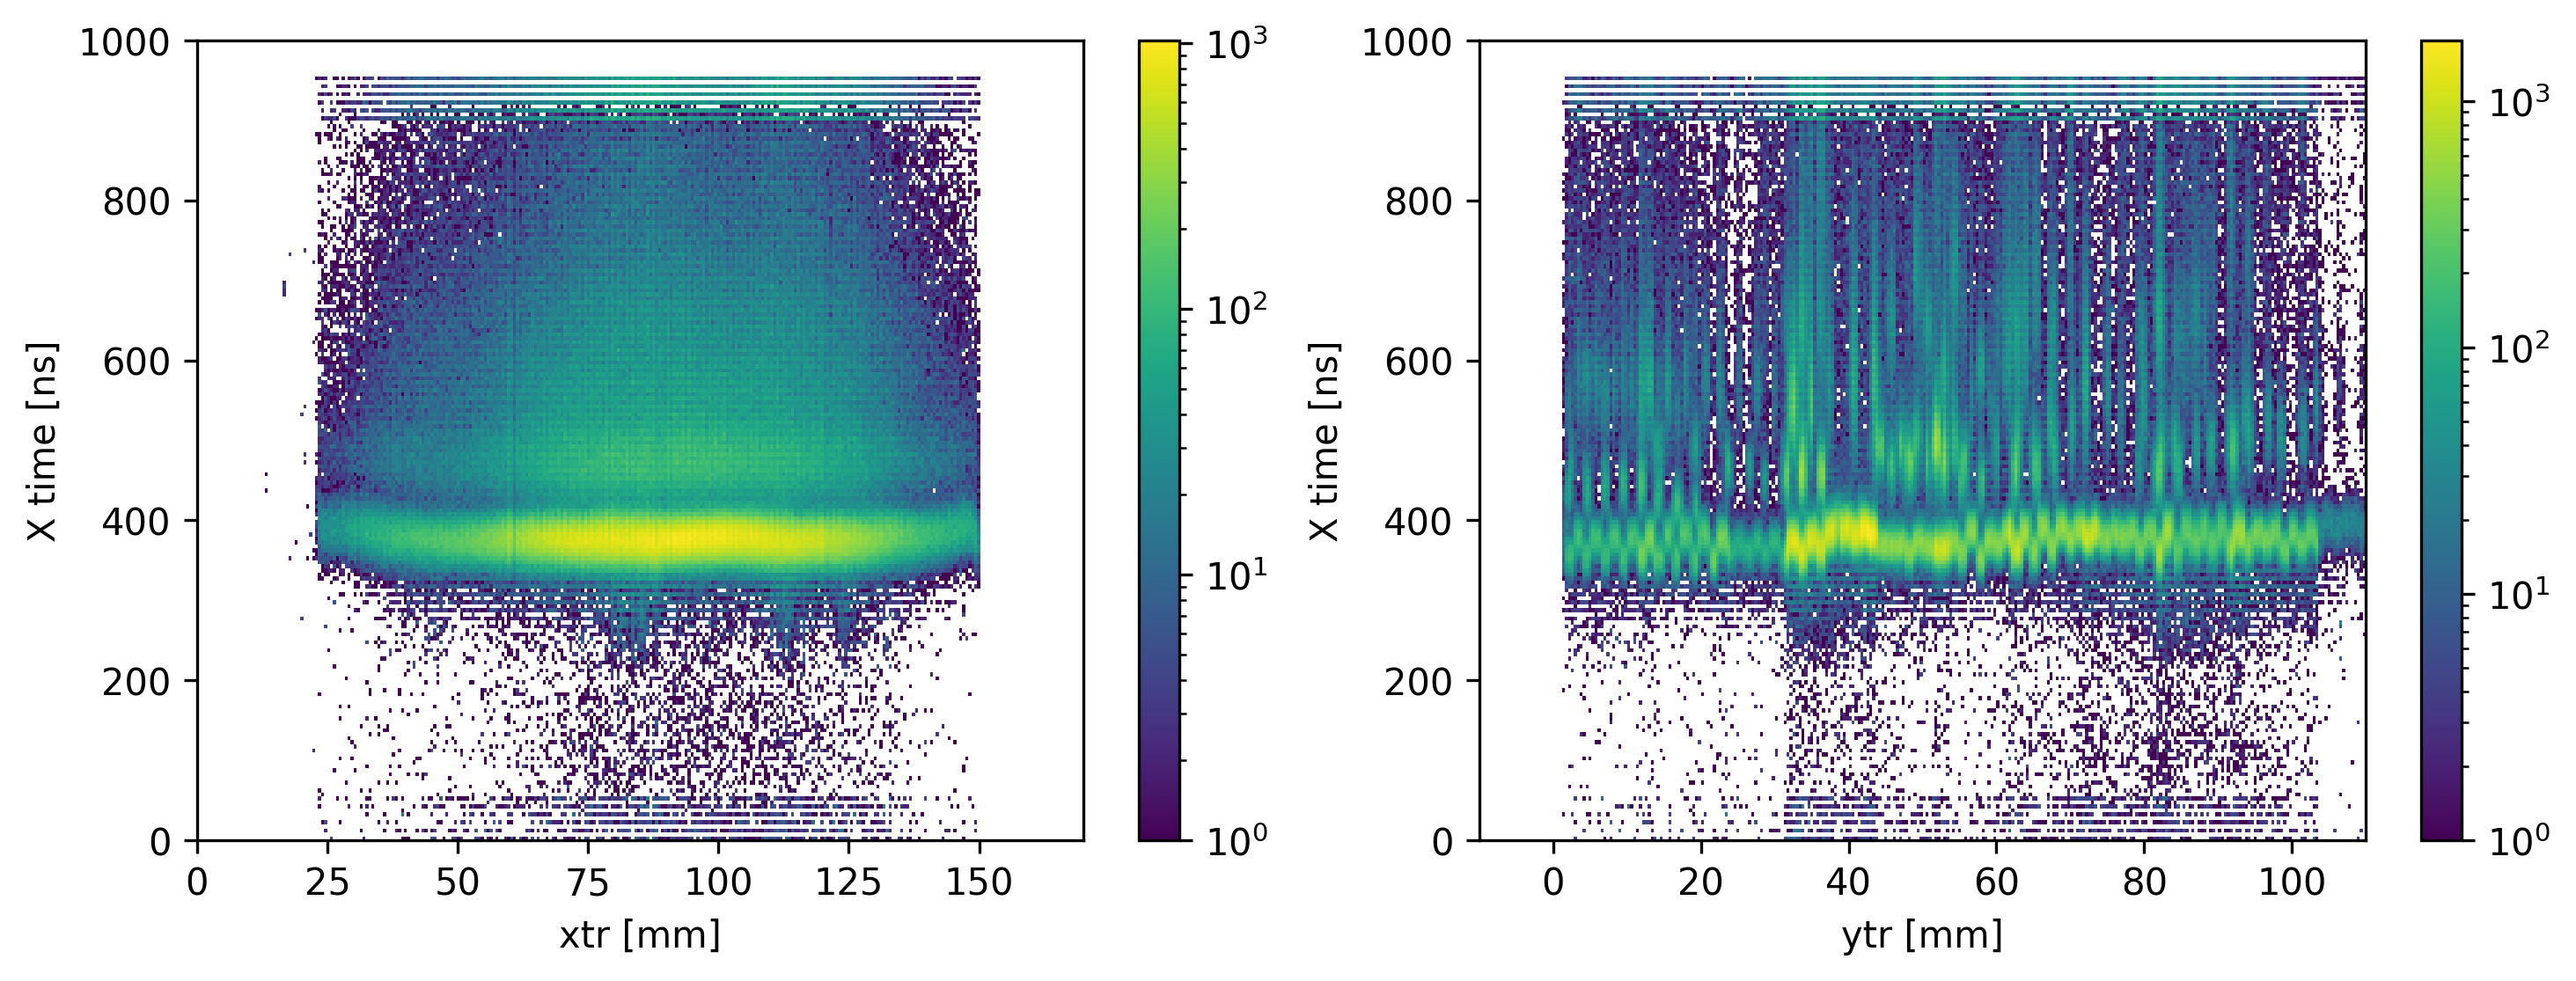

In [14]:
fig = plt.figure( figsize=(10,7) )
ax = fig.add_subplot(221)
hx = ax.hist2d( df0['xtr'],df0['Xt'], bins=(300,200), range=[ [0,170],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("xtr [mm]")
# ax.set_title("all")

ax = fig.add_subplot(222)
hx = ax.hist2d( df0['ytr'],df0['Xt'], bins=(300,200), range=[ [-10,110],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("ytr [mm]")
# ax.set_title("all")


Text(0.5, 0, 'ytr [mm]')

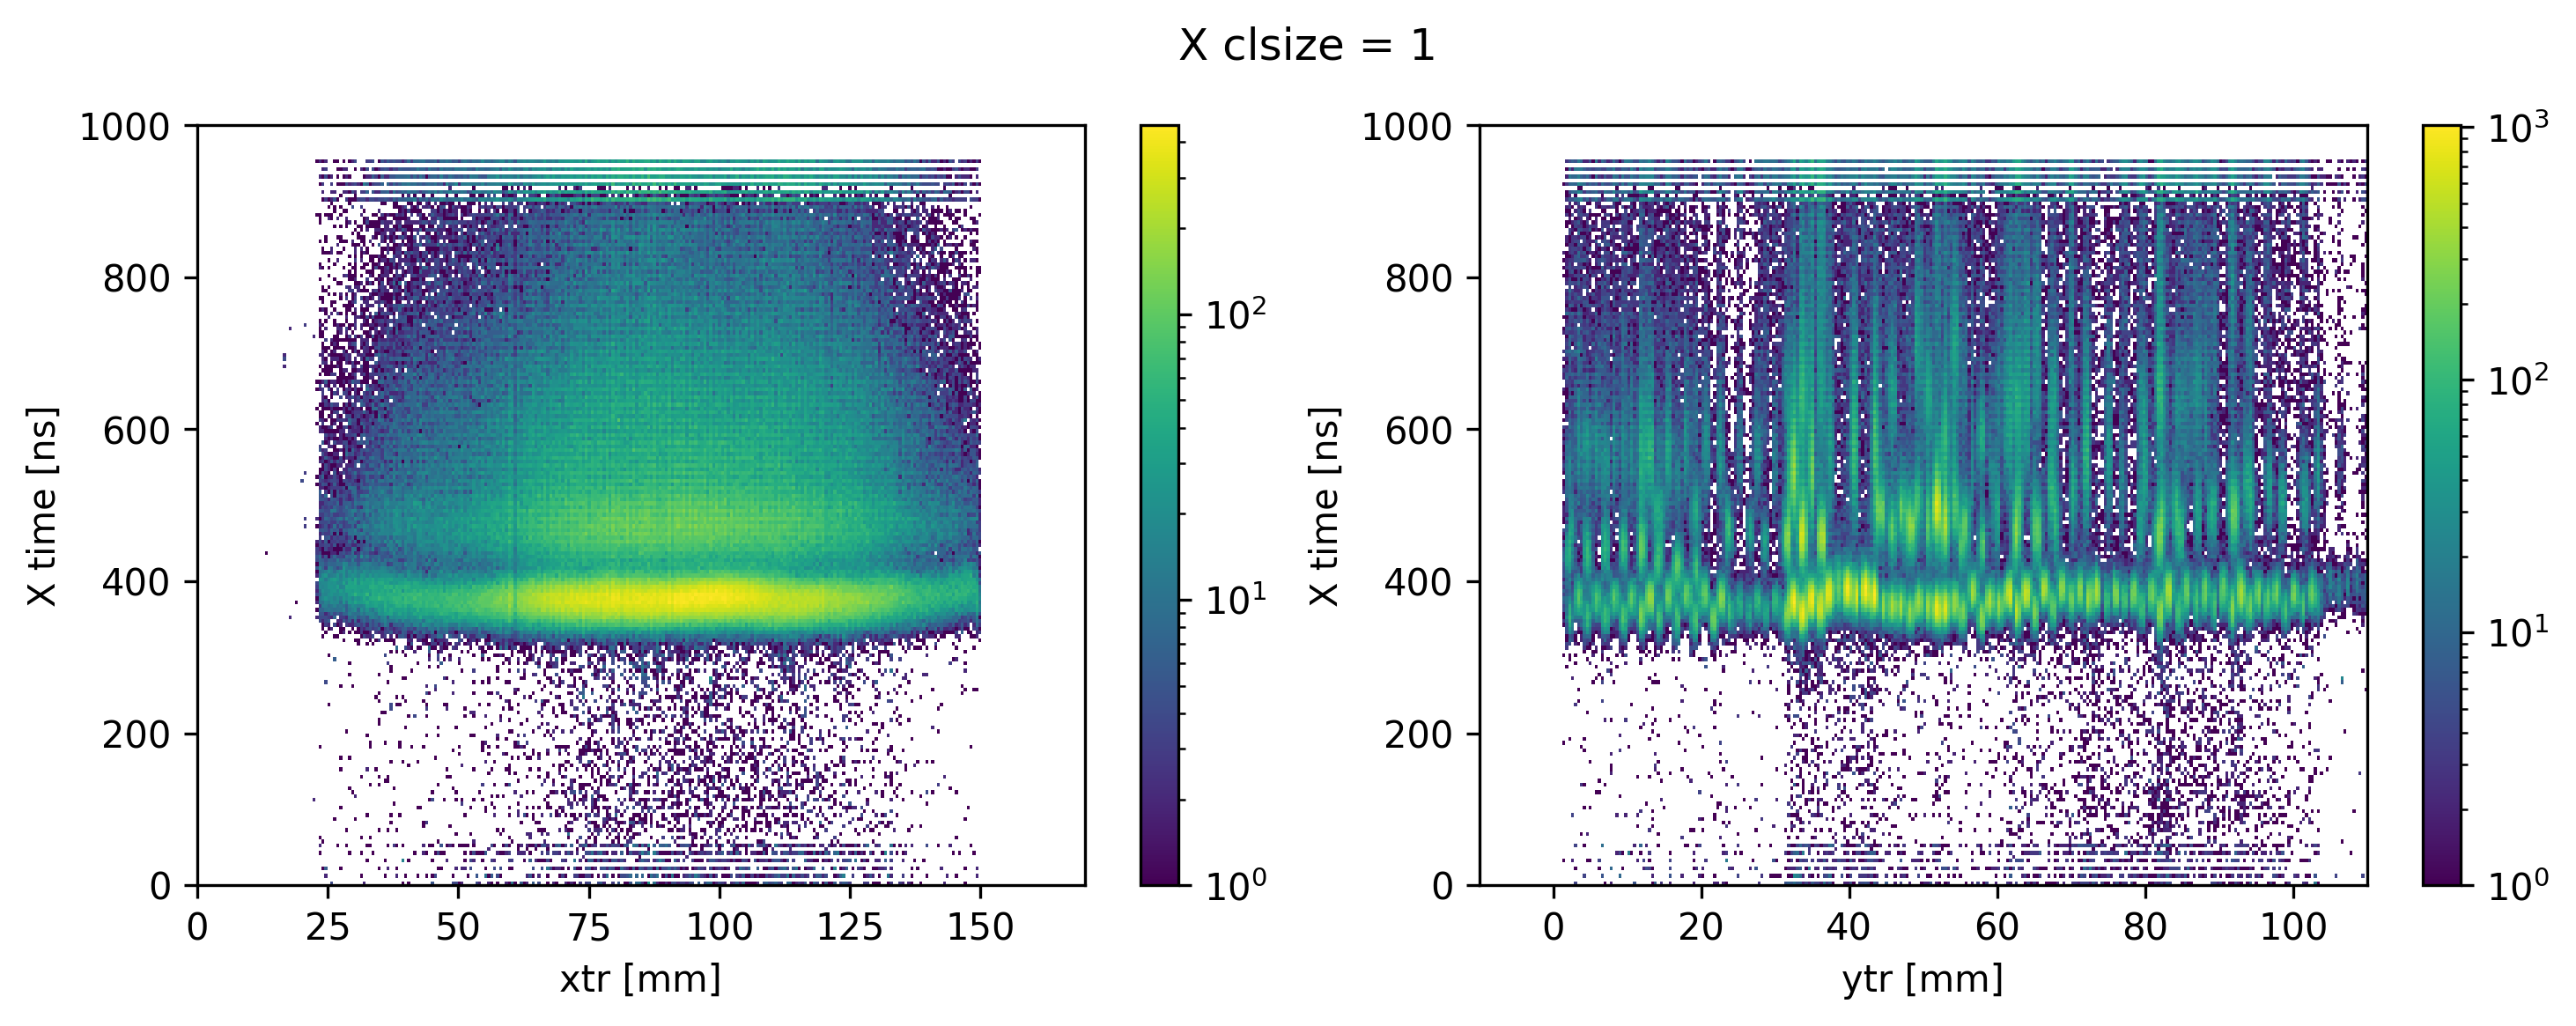

In [15]:
fig = plt.figure( figsize=(10,7) )
fig.suptitle("X clsize = 1")
ax = fig.add_subplot(221)
hx = ax.hist2d( df0Xcls1['xtr'],df0Xcls1['Xt'], bins=(300,200), range=[ [0,170],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("xtr [mm]")
# ax.set_title("all")

ax = fig.add_subplot(222)
hx = ax.hist2d( df0Xcls1['ytr'],df0Xcls1['Xt'], bins=(300,200), range=[ [-10,110],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("ytr [mm]")

Text(0.5, 0, 'ytr [mm]')

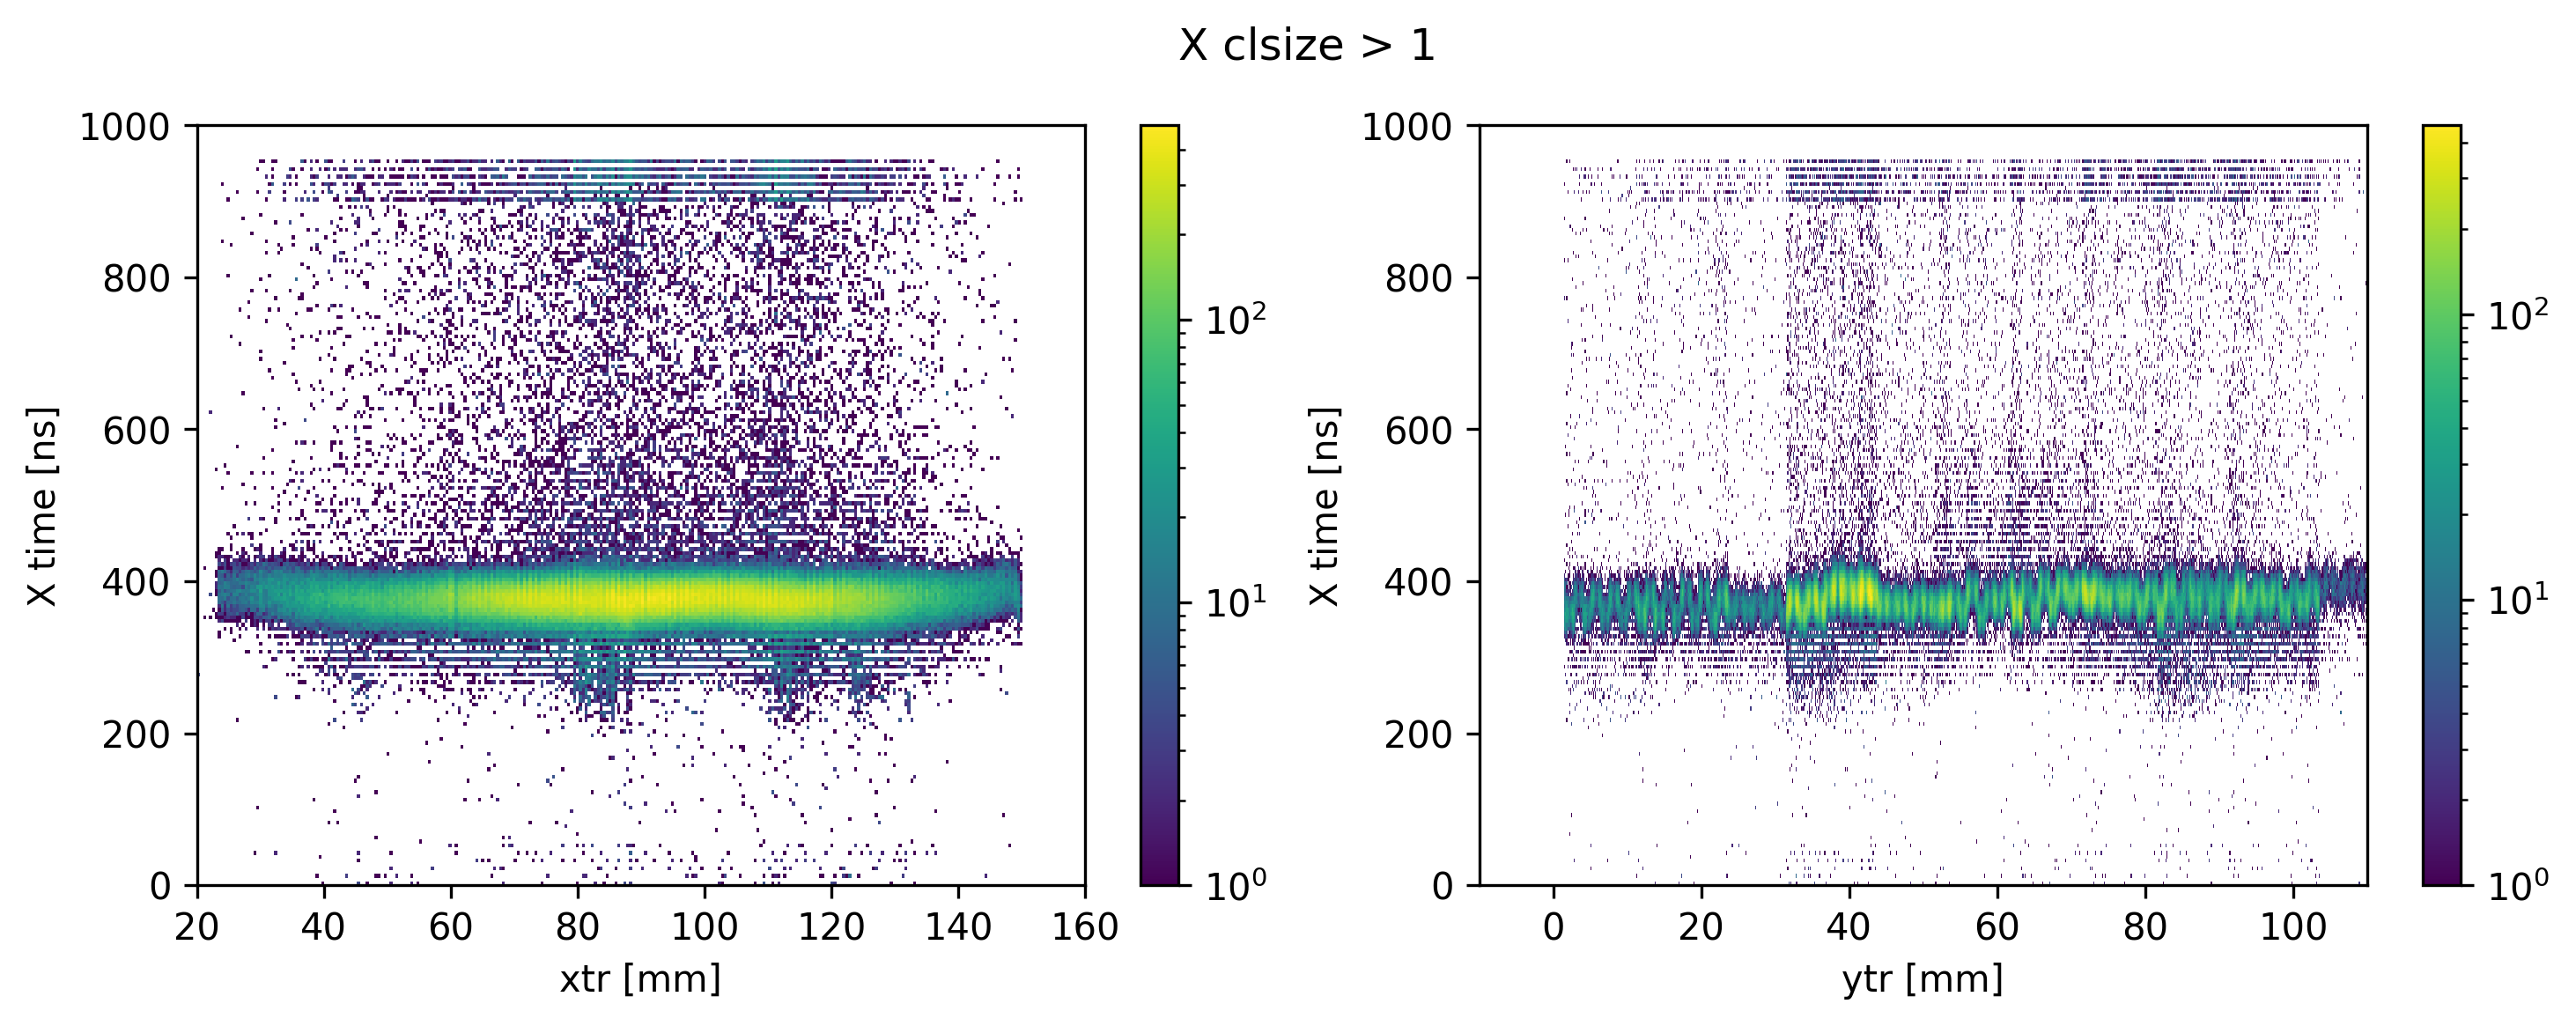

In [16]:
fig = plt.figure( figsize=(10,7) )
fig.suptitle("X clsize > 1")
ax = fig.add_subplot(221)
hx = ax.hist2d( df0XclsL['xtr'],df0XclsL['Xt'], bins=(300,200), range=[ [20,160],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("xtr [mm]")
# ax.set_title("all")

ax = fig.add_subplot(222)
hx = ax.hist2d( df0XclsL['ytr'],df0XclsL['Xt'], bins=(960,200), range=[ [-10,110],[0,1000] ], cmin=1, norm=colors.LogNorm() )
fig.colorbar(hx[3], ax=ax)
ax.set_ylabel("X time [ns]")
ax.set_xlabel("ytr [mm]")

##### Y strips

Text(0.5, 0, 'ytr [mm]')

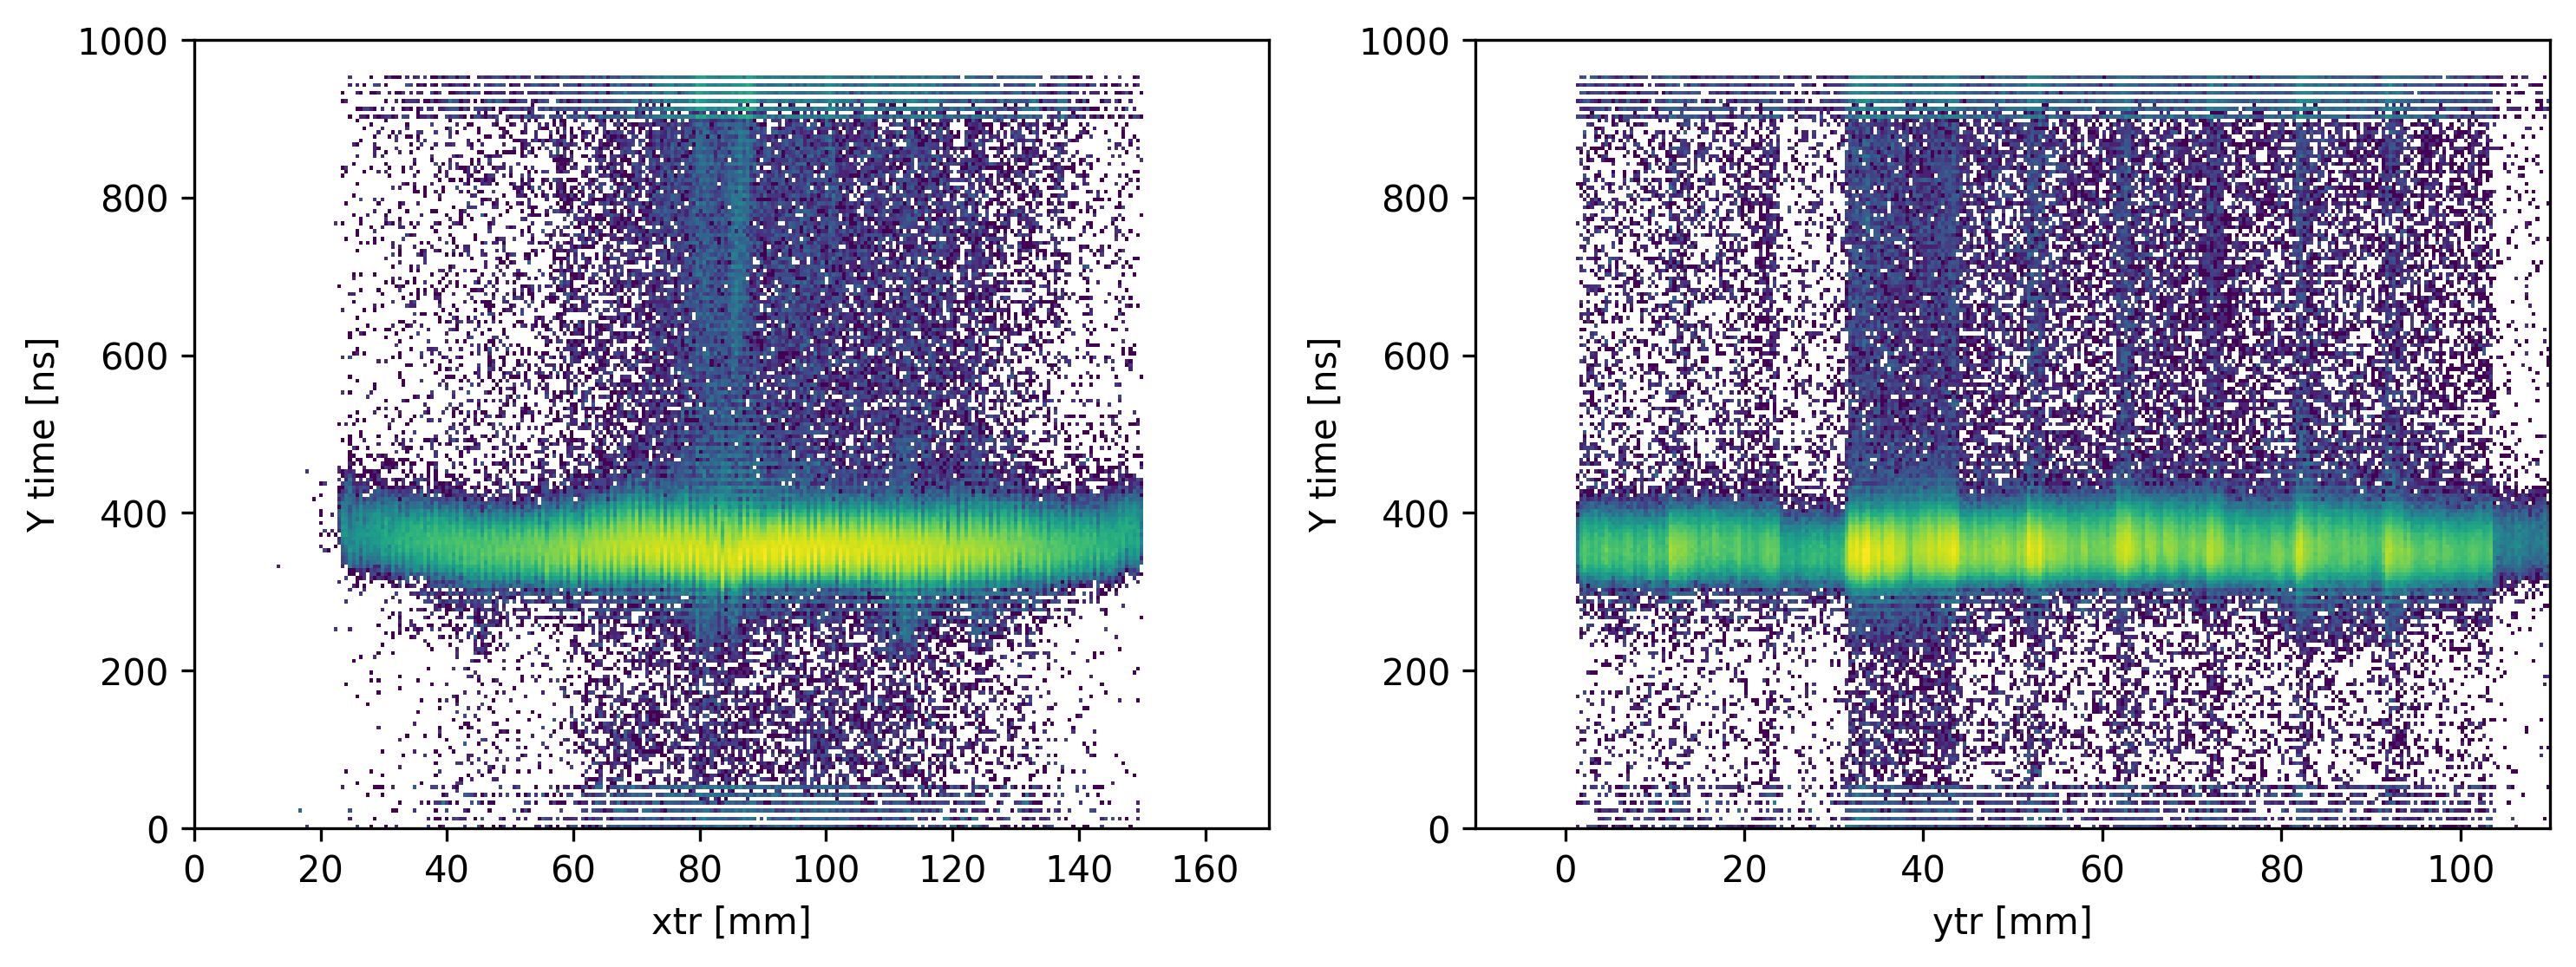

In [17]:
fig = plt.figure( figsize=(10,7) )
ay = fig.add_subplot(221)
hx = ay.hist2d( df0['xtr'],df0['Yt'], bins=(300,200), range=[ [0,170],[0,1000] ], cmin=1, norm=colors.LogNorm() )
# fig.colorbar(hx[3], ay=ay)
ay.set_ylabel("Y time [ns]")
ay.set_xlabel("xtr [mm]")
# ay.set_title("all")

ay = fig.add_subplot(222)
hx = ay.hist2d( df0['ytr'],df0['Yt'], bins=(300,200), range=[ [-10,110],[0,1000] ], cmin=1, norm=colors.LogNorm() )
# fig.colorbar(hx[3], ay=ay)
ay.set_ylabel("Y time [ns]")
ay.set_xlabel("ytr [mm]")

#### Time versus amplitude

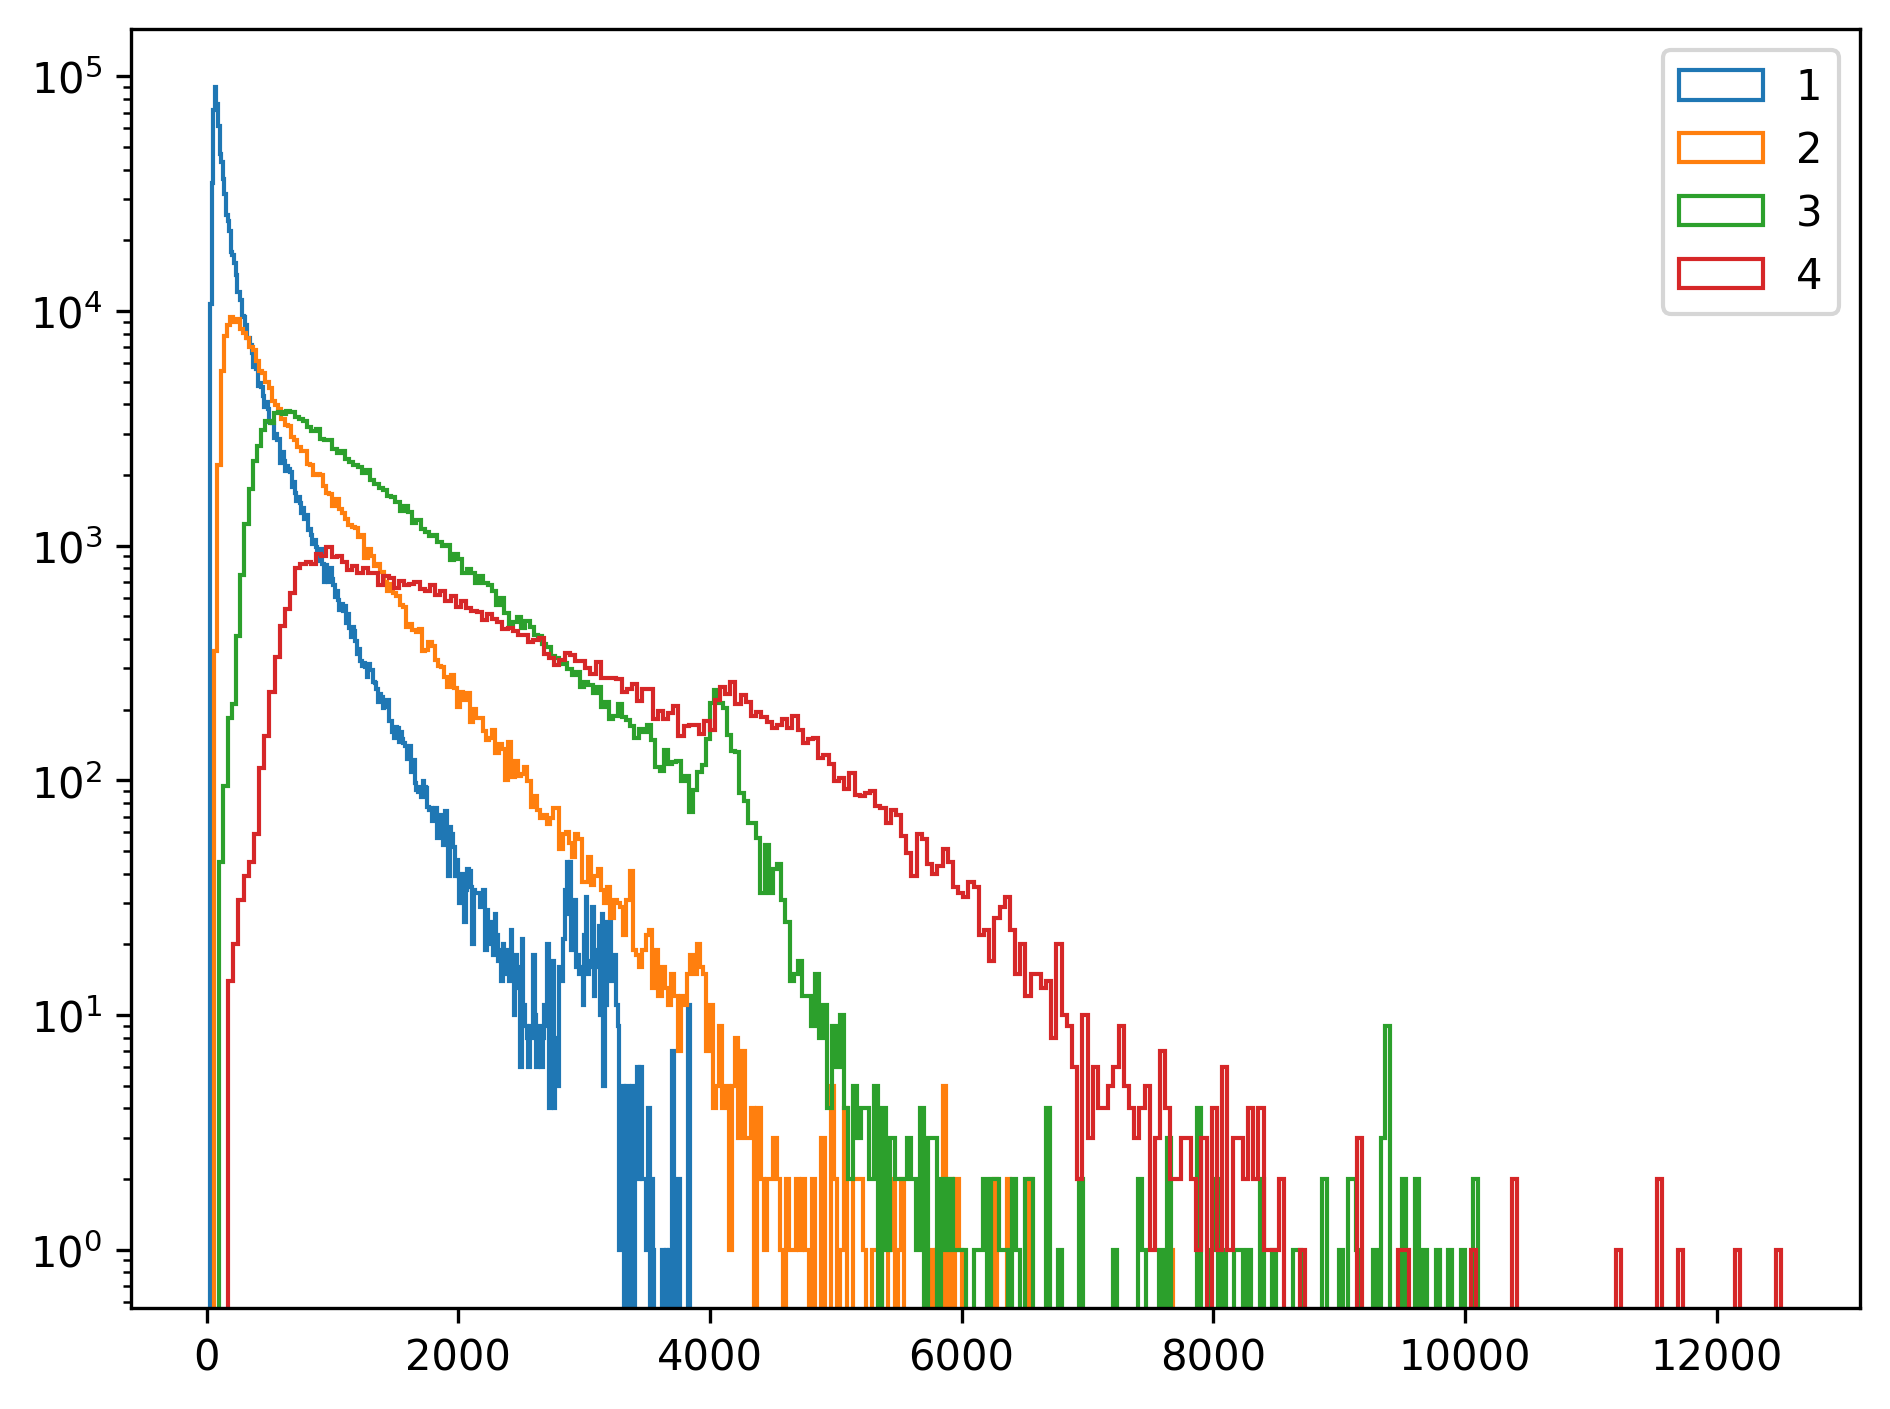

In [18]:
for i in range(1,5):
    plt.hist( df0[ df0['Xclsize']==i ]['Xmaxamp'],bins=300, histtype='step',label=str(i) );
plt.yscale('log')
plt.legend()

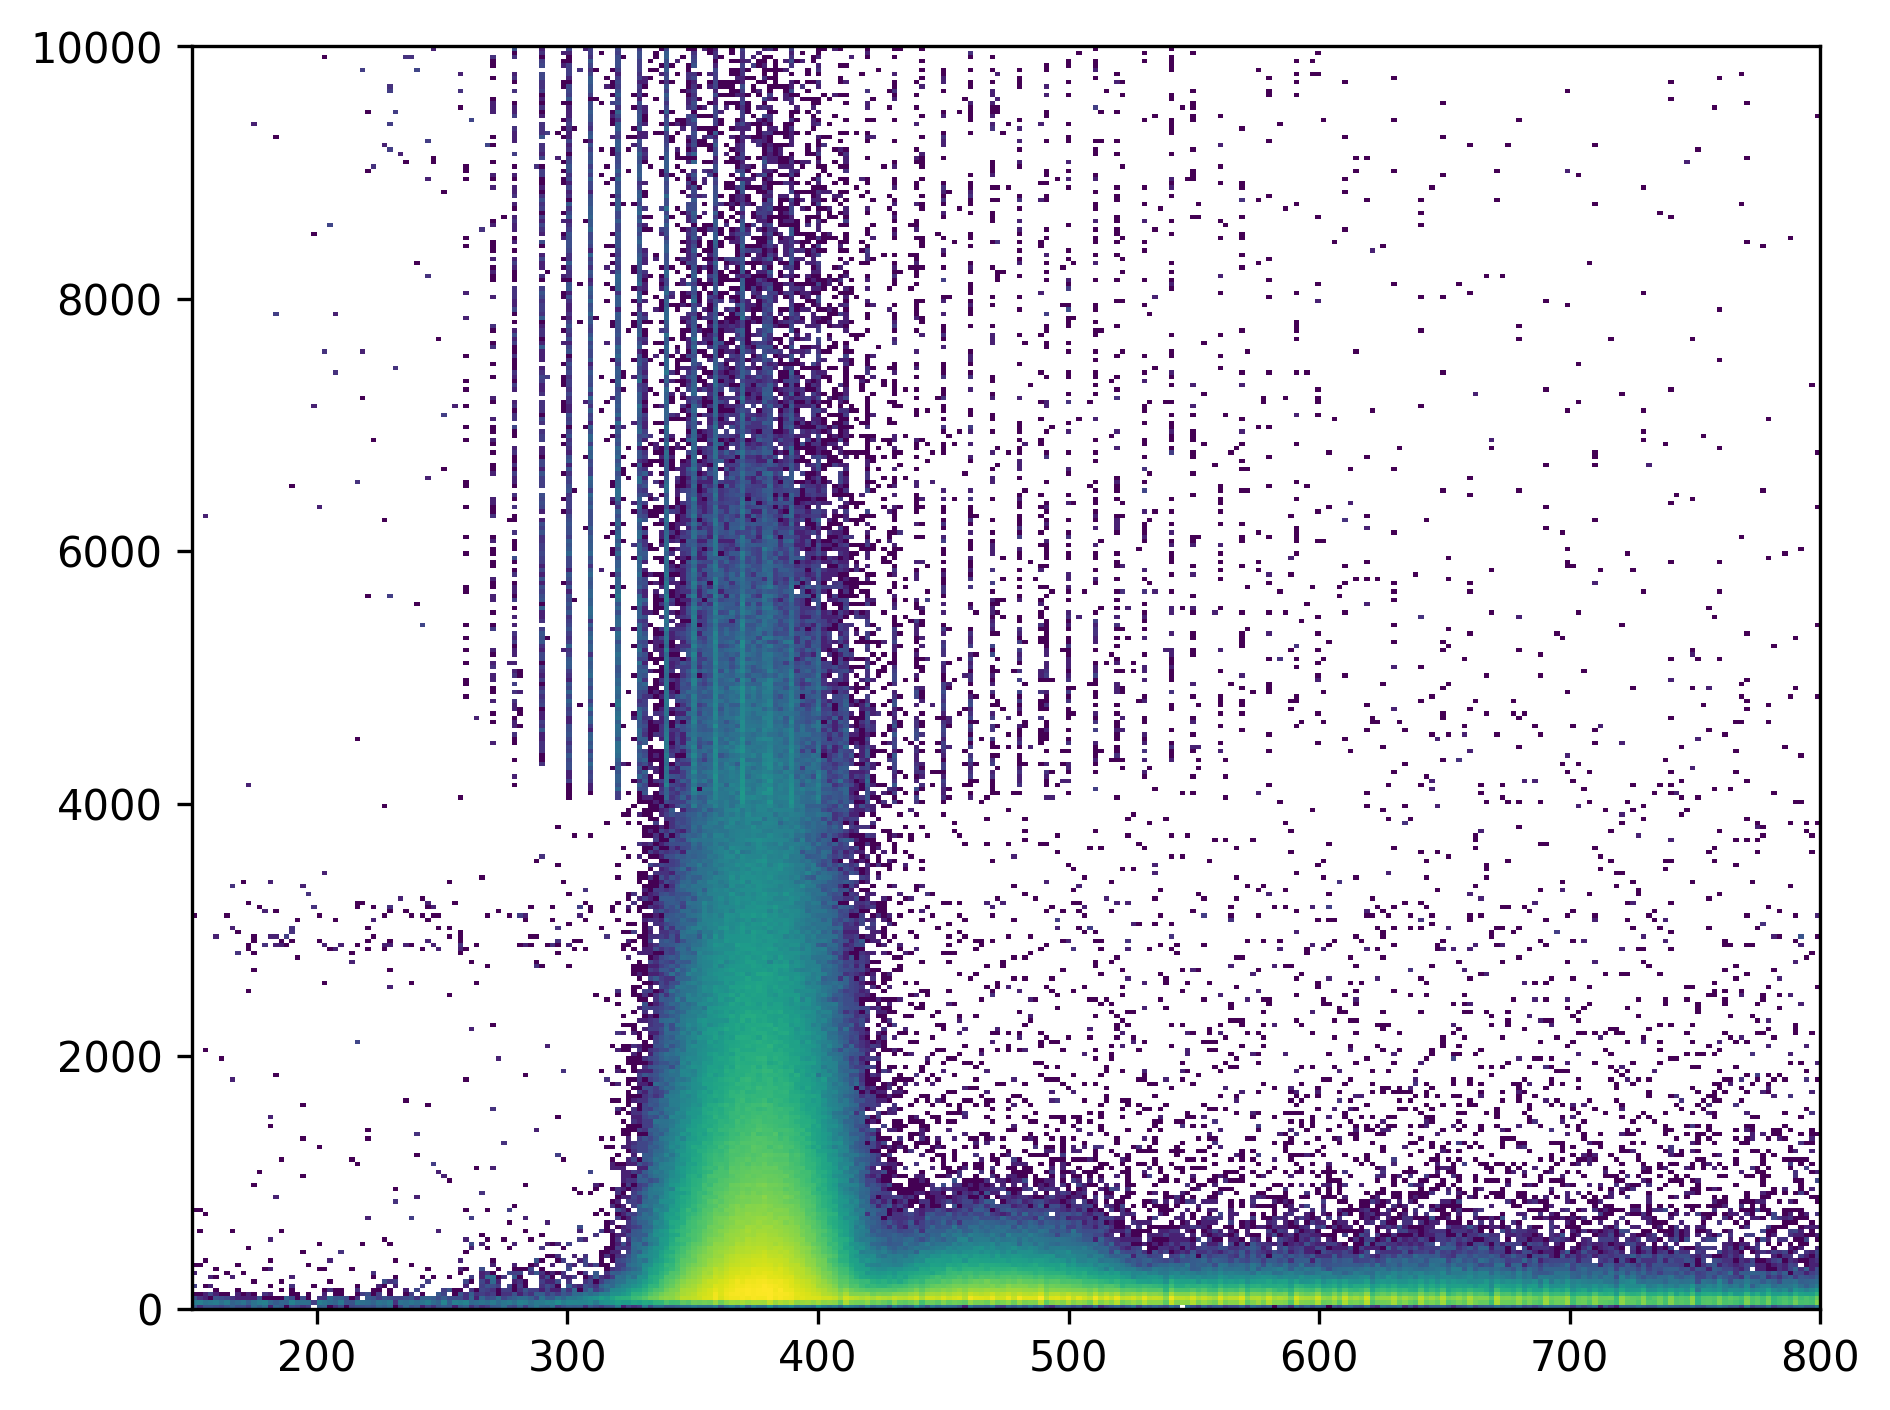

In [19]:
hx = plt.hist2d( df0['Xt'],df0['Xmaxamp'], bins=(300,300), range=[[150,800],[0,10000] ], cmin=1, norm=colors.LogNorm() )

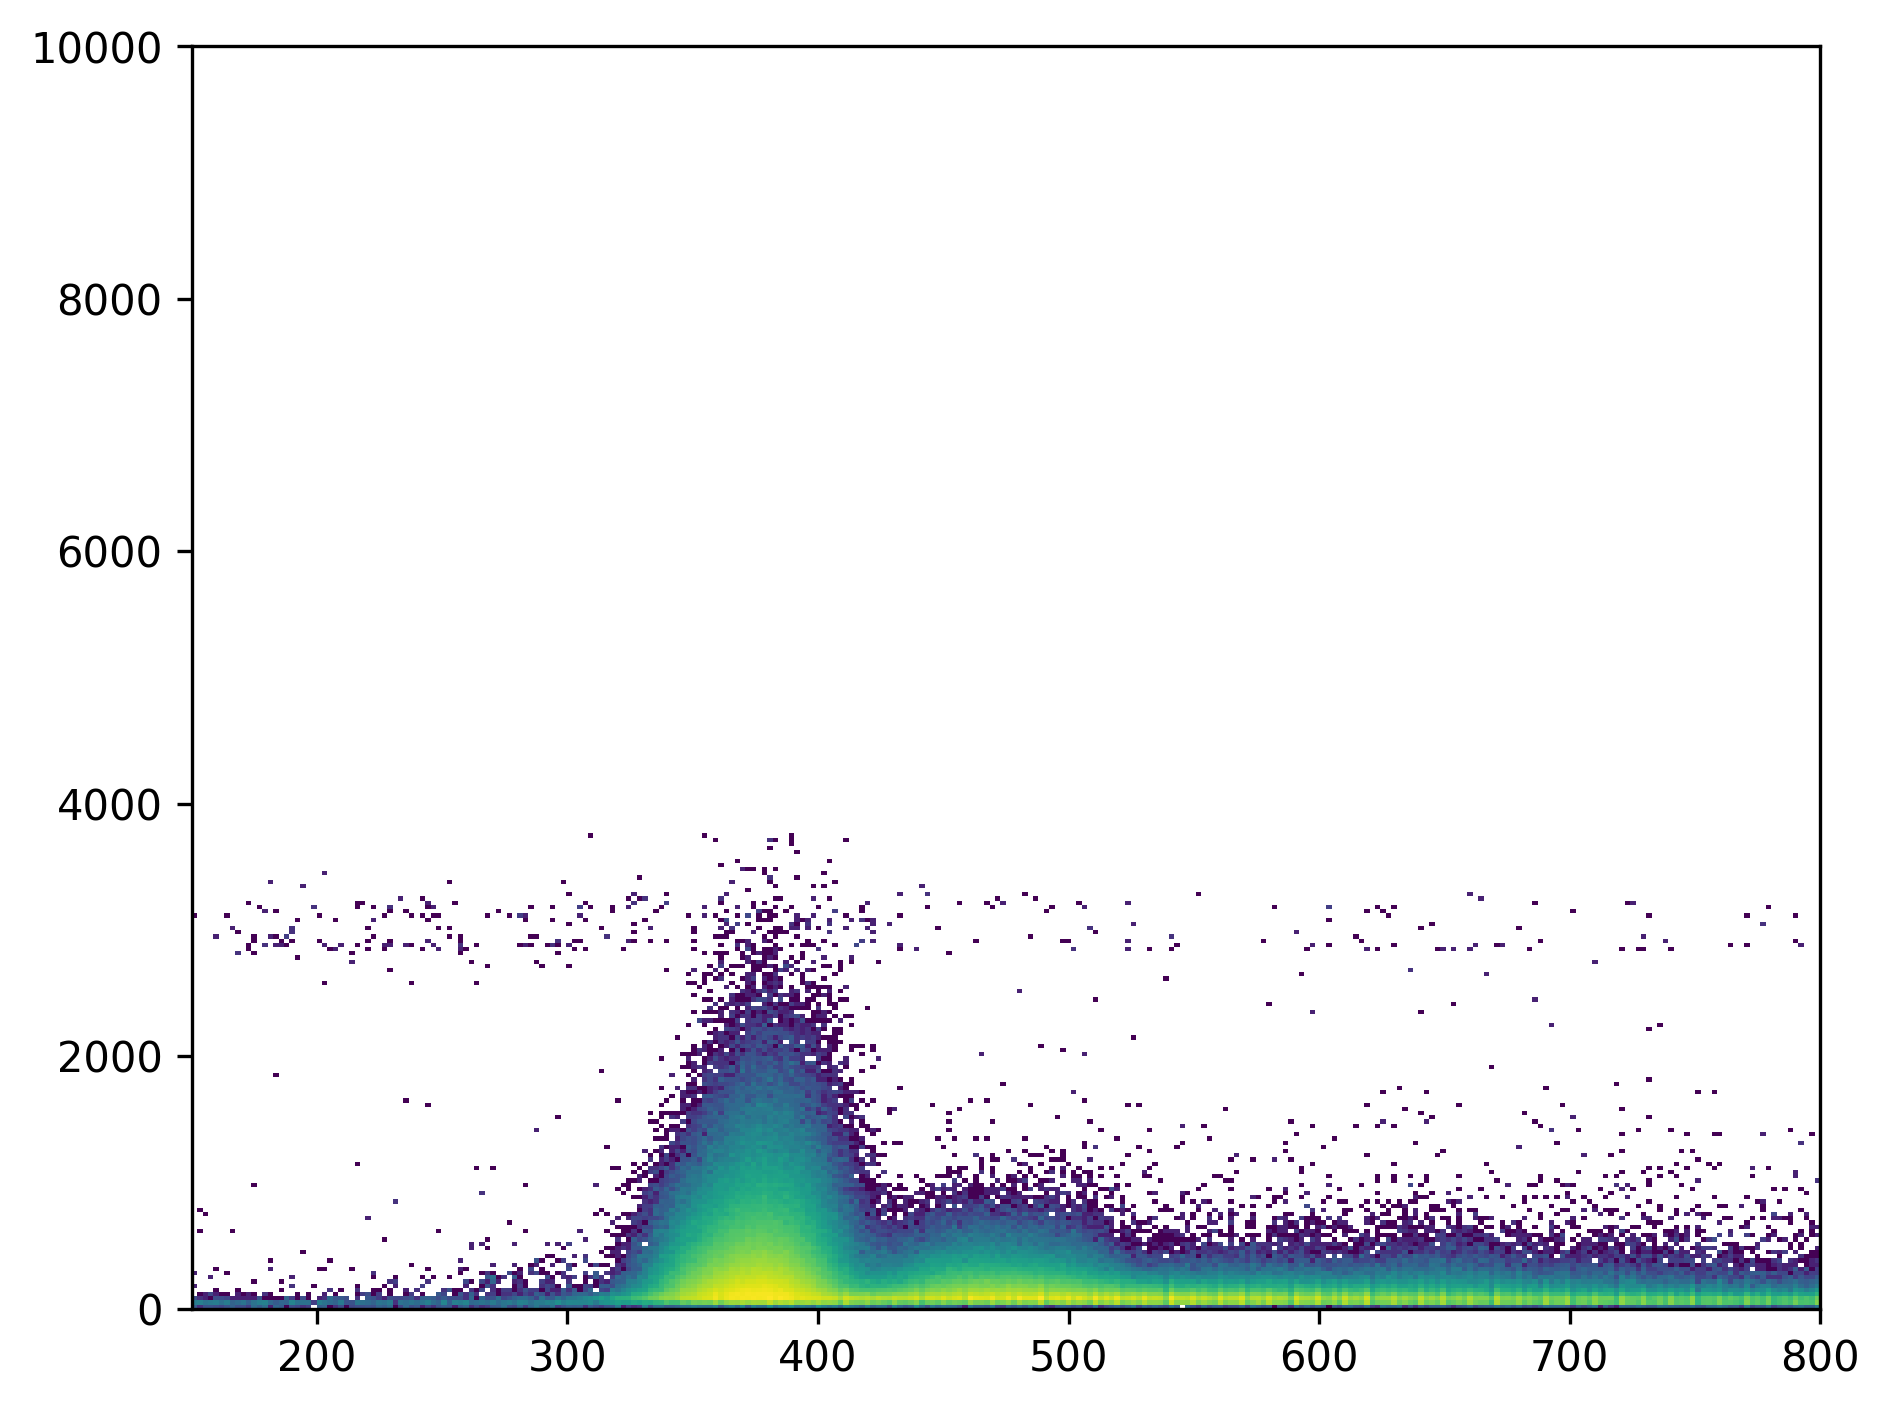

In [20]:
hx = plt.hist2d( df0Xcls1['Xt'],df0Xcls1['Xmaxamp'], bins=(300,300), range=[[150,800],[0,10000] ], cmin=1, norm=colors.LogNorm() )

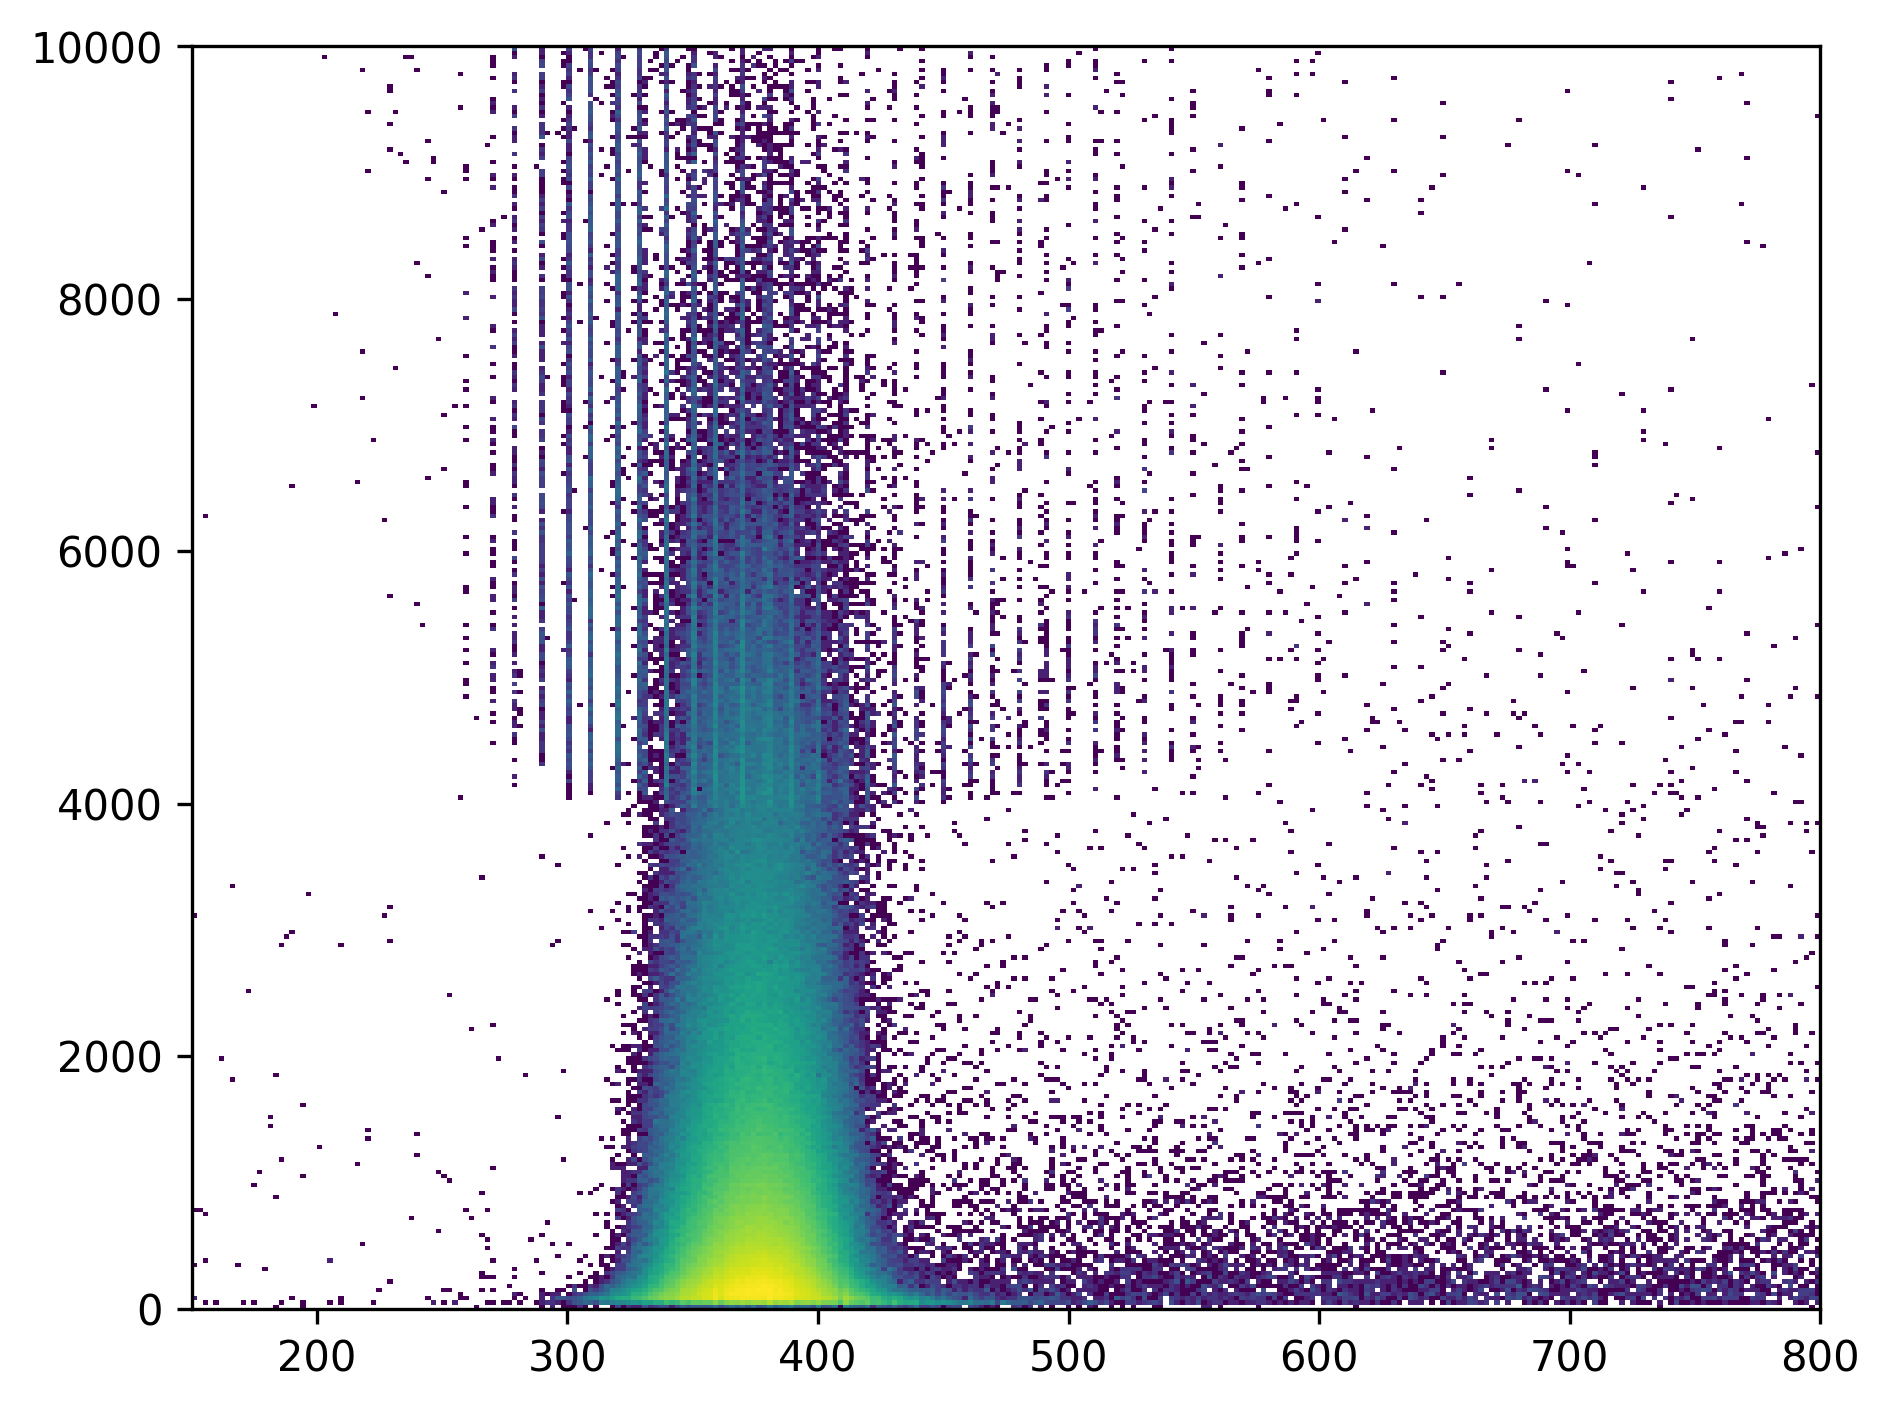

In [21]:
hx = plt.hist2d( dft['Xt'],dft['Xmaxamp'], bins=(300,300), range=[[150,800],[0,10000] ], cmin=1, norm=colors.LogNorm() )

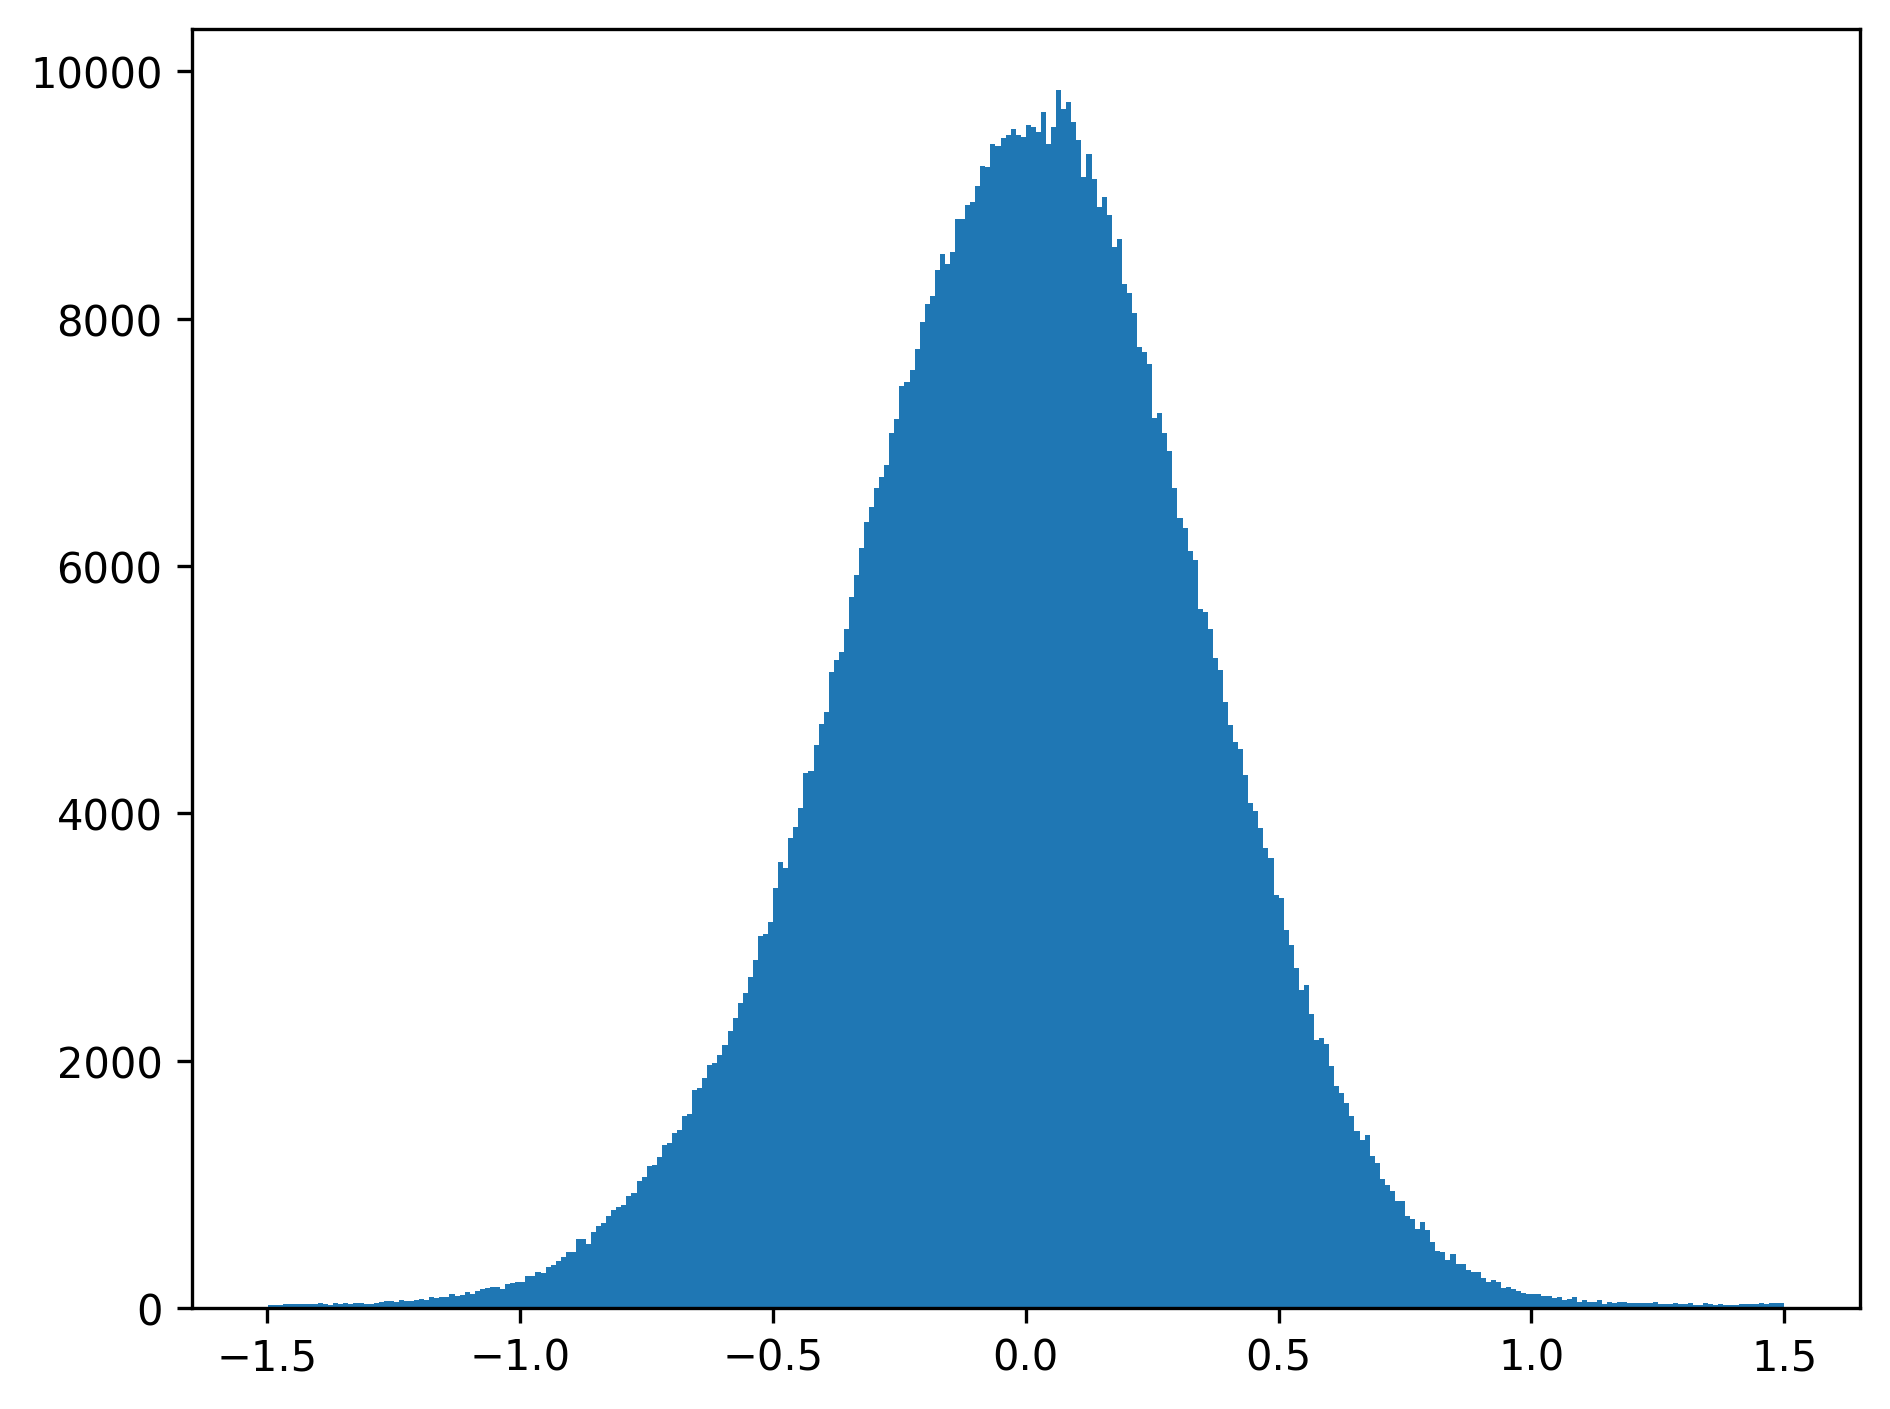

In [22]:
plt.hist( dft['yres'], bins=300);

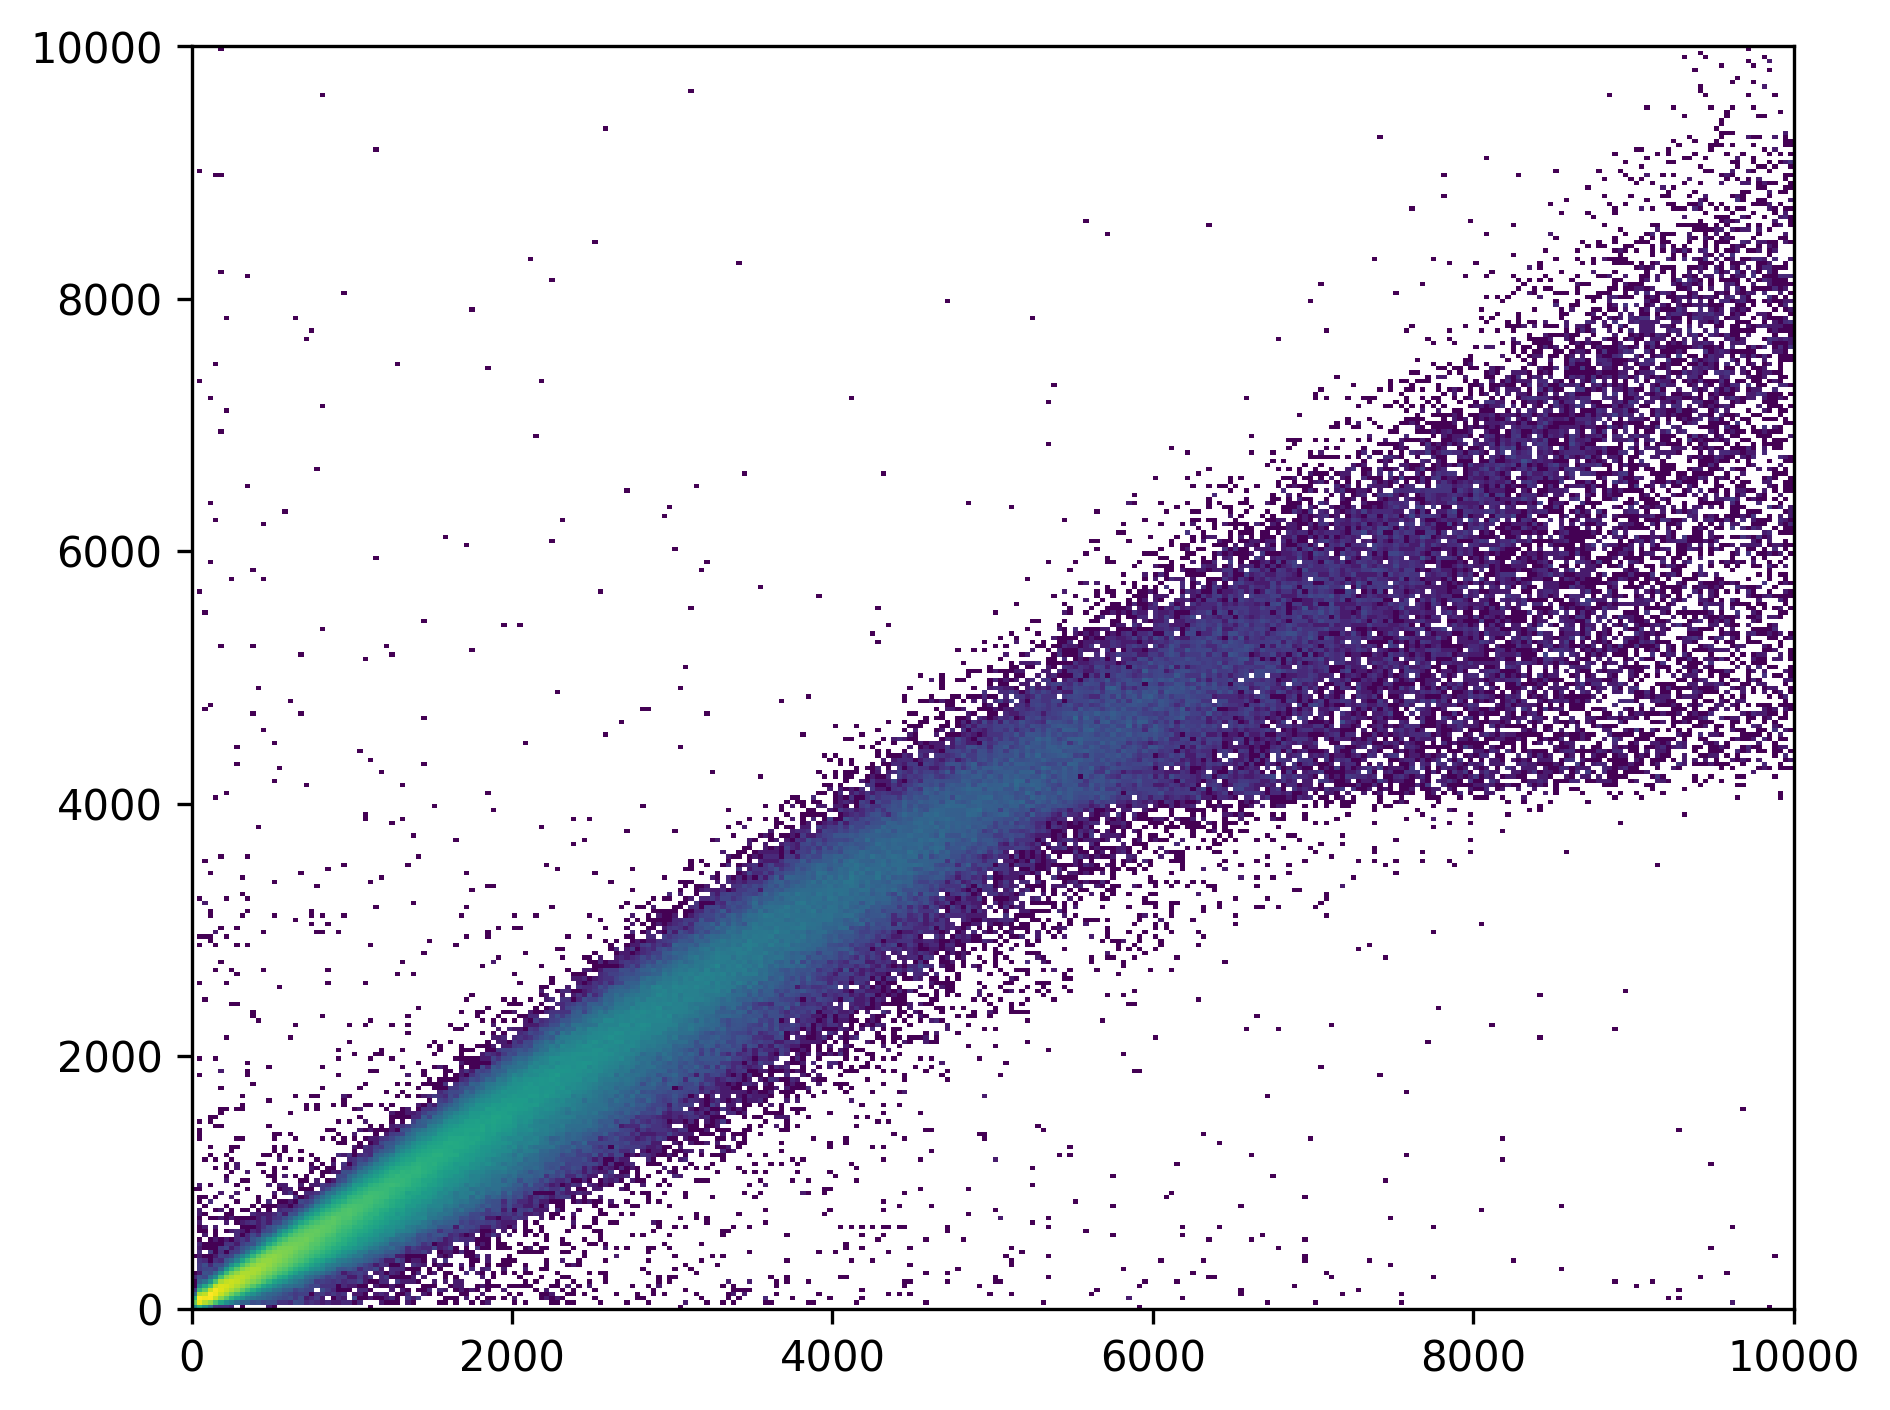

In [23]:
hx = plt.hist2d( dft['Ymaxamp'],dft['Xmaxamp'], bins=(300,300), range=[[0,10000],[0,10000] ], cmin=1, norm=colors.LogNorm() )

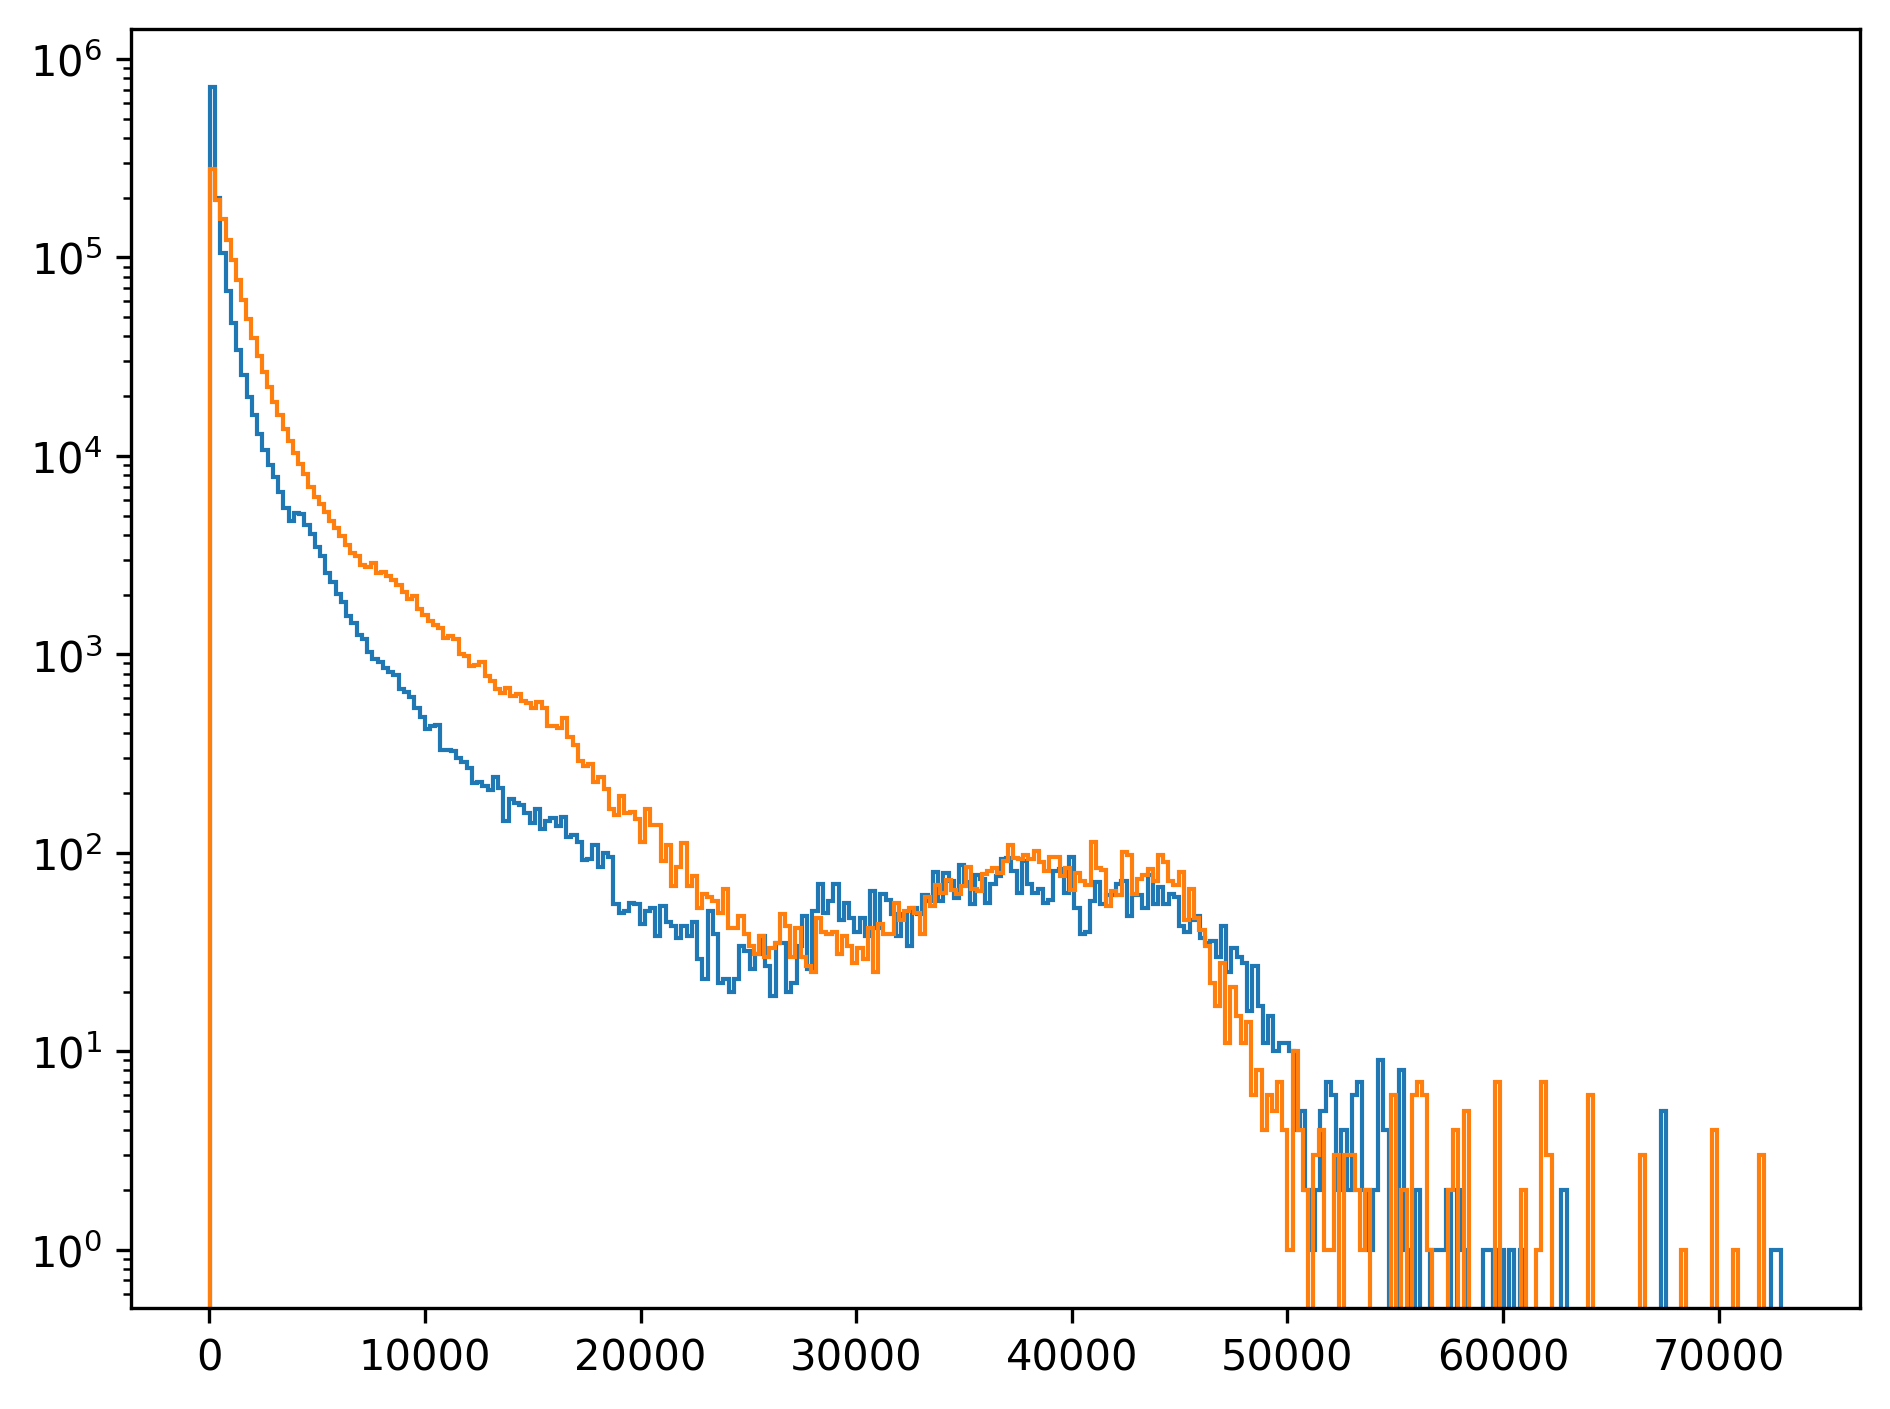

In [24]:
plt.hist( df0['Xmaxamp'], bins=300,histtype='step');
plt.hist( df0['Ymaxamp'], bins=300,histtype='step');
plt.yscale('log')